In [ ]:
# Reproducibility
SEED = 42

import random
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import scipy
scipy.interp = np.interp  # compatibility fix for scikit-plot

import pandas as pd
import math
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    log_loss,
    brier_score_loss
)

from sklearn.preprocessing import OneHotEncoder

import fairlearn as fl
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio
)

import xgboost as xgb
from xgboost import plot_importance

from scipy.stats import wasserstein_distance

# Optional display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [ ]:
# =========================
# Helper functions
# =========================

THRESHOLD = 0.5

def encode_train_test(X_train, X_test):
    """
    Fit one-hot encoding on the training data only
    and apply the same transformation to the test data.
    """
    cat_cols = X_train.select_dtypes(include=["category", "object"]).columns.tolist()
    num_cols = [col for col in X_train.columns if col not in cat_cols]

    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

    X_train_cat = encoder.fit_transform(X_train[cat_cols])
    X_test_cat = encoder.transform(X_test[cat_cols])

    encoded_col_names = encoder.get_feature_names_out(cat_cols)

    X_train_cat_df = pd.DataFrame(
        X_train_cat,
        columns=encoded_col_names,
        index=X_train.index
    )

    X_test_cat_df = pd.DataFrame(
        X_test_cat,
        columns=encoded_col_names,
        index=X_test.index
    )

    X_train_num = X_train[num_cols].copy()
    X_test_num = X_test[num_cols].copy()

    X_train_encoded = pd.concat([X_train_num, X_train_cat_df], axis=1)
    X_test_encoded = pd.concat([X_test_num, X_test_cat_df], axis=1)

    return X_train_encoded, X_test_encoded, encoder, cat_cols, num_cols

def summarize_binary_predictions(y_true, pred_prob, threshold=THRESHOLD):
    pred_class = (pred_prob >= threshold).astype(int)

    results = {
        "accuracy": accuracy_score(y_true, pred_class),
        "auc": roc_auc_score(y_true, pred_prob),
        "log_loss": log_loss(y_true, pred_prob),
        "brier_score": brier_score_loss(y_true, pred_prob),
        "mean_prediction": float(np.mean(pred_prob))
    }
    return results, pred_class

def plot_binary_confusion_matrix(y_true, pred_class, title):
    cm = confusion_matrix(y_true, pred_class)

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

def safe_ratio(num, den):
    if den == 0:
        return np.nan
    return num / den

def compute_fairness_metrics(y_true, pred_prob, pred_class, sensitive_series, scheme_name):
    """
    Compute fairness metrics for one prediction scheme.
    """
    sensitive_series = pd.Series(sensitive_series).reset_index(drop=True)
    y_true = pd.Series(y_true).reset_index(drop=True)
    pred_prob = pd.Series(pred_prob).reset_index(drop=True)
    pred_class = pd.Series(pred_class).reset_index(drop=True)

    mask_0 = sensitive_series == 0
    mask_1 = sensitive_series == 1

    group0_probs = pred_prob[mask_0]
    group1_probs = pred_prob[mask_1]

    mean_prob_0 = group0_probs.mean()
    mean_prob_1 = group1_probs.mean()

    fairness_row = pd.DataFrame({
        "scheme": [scheme_name],
        "dp_ratio_binary": [
            demographic_parity_ratio(
                y_true=y_true,
                y_pred=pred_class,
                sensitive_features=sensitive_series
            )
        ],
        "dp_difference_binary": [
            demographic_parity_difference(
                y_true=y_true,
                y_pred=pred_class,
                sensitive_features=sensitive_series
            )
        ],
        "dp_ratio_probability": [
            safe_ratio(mean_prob_1, mean_prob_0)
        ],
        "dp_difference_probability": [
            mean_prob_1 - mean_prob_0
        ],
        "wasserstein_probability": [
            wasserstein_distance(group0_probs, group1_probs)
        ],
        "equalized_odds_ratio_binary": [
            equalized_odds_ratio(
                y_true=y_true,
                y_pred=pred_class,
                sensitive_features=sensitive_series
            )
        ],
        "mean_pred_prob_group0": [mean_prob_0],
        "mean_pred_prob_group1": [mean_prob_1]
    })

    return fairness_row

def transform_with_fitted_encoder(X_new, encoder, cat_cols, num_cols):
    X_new_cat = encoder.transform(X_new[cat_cols])
    encoded_col_names = encoder.get_feature_names_out(cat_cols)

    X_new_cat_df = pd.DataFrame(
        X_new_cat,
        columns=encoded_col_names,
        index=X_new.index
    )

    X_new_num = X_new[num_cols].copy()

    X_new_encoded = pd.concat([X_new_num, X_new_cat_df], axis=1)
    return X_new_encoded

def compute_scheme_gap_table(pred_dict, sensitive_series, model_name):
    """
    Compare prediction gaps across pricing schemes.
    pred_dict: dictionary like
        {
            "Best-estimate": pred_best,
            "Unawareness": pred_unaw,
            "Aware": pred_aware
        }
    """
    sensitive_series = pd.Series(sensitive_series).reset_index(drop=True)

    scheme_pairs = [
        ("Best-estimate", "Unawareness"),
        ("Best-estimate", "Aware"),
        ("Unawareness", "Aware")
    ]

    rows = []

    for scheme_a, scheme_b in scheme_pairs:
        pred_a = pd.Series(pred_dict[scheme_a]).reset_index(drop=True)
        pred_b = pd.Series(pred_dict[scheme_b]).reset_index(drop=True)

        gap = pred_a - pred_b

        row = {
            "model": model_name,
            "comparison": f"{scheme_a} - {scheme_b}",
            "mean_signed_gap": gap.mean(),
            "mean_absolute_gap": gap.abs().mean(),
            "mean_gap_group0": gap[sensitive_series == 0].mean(),
            "mean_gap_group1": gap[sensitive_series == 1].mean()
        }

        rows.append(row)

    return pd.DataFrame(rows)


def build_thesis_interpretation_table(core_table):
    """
    Build a clean interpretation table relative to Best-estimate within each model.
    """
    rows = []

    for model_name in core_table["model"].unique():
        model_df = core_table[core_table["model"] == model_name].copy()

        baseline = model_df[model_df["scheme"] == "Best-estimate"].iloc[0]

        for _, row in model_df.iterrows():
            rows.append({
                "model": row["model"],
                "scheme": row["scheme"],
                "auc": row["auc"],
                "log_loss": row["log_loss"],
                "brier_score": row["brier_score"],
                "dp_difference_probability": row["dp_difference_probability"],
                "wasserstein_probability": row["wasserstein_probability"],
                "delta_auc_vs_best_estimate": row["auc"] - baseline["auc"],
                "delta_log_loss_vs_best_estimate": row["log_loss"] - baseline["log_loss"],
                "delta_brier_vs_best_estimate": row["brier_score"] - baseline["brier_score"],
                "delta_dp_diff_vs_best_estimate": row["dp_difference_probability"] - baseline["dp_difference_probability"],
                "delta_wasserstein_vs_best_estimate": row["wasserstein_probability"] - baseline["wasserstein_probability"]
            })

    return pd.DataFrame(rows)


In [ ]:
# =========================
# 2. Load raw data
# =========================

df_raw = pd.read_csv("/content/freMTPL2freq2.csv", sep=",", decimal=",")

# Basic type cleaning
df_raw["Exposure"] = df_raw["Exposure"].astype("float64")

categorical_vars = ["VehPower", "Area", "VehBrand", "VehGas", "Region"]
for col in categorical_vars:
    df_raw[col] = df_raw[col].astype("category")

# Optional quick checks
print(df_raw.shape)
print(df_raw.dtypes)
print(df_raw.head())

# =========================
# 3. Create enriched fairness dataset
# =========================

df_fair = df_raw.copy()

# 3.1 Binary claims target from original claim count
df_fair["Claims"] = np.where(df_fair["ClaimNb"] == 0, 0, 1)

# 3.2 Synthetic neutral protected variable (benchmark only)
df_fair["SexNeutral"] = np.random.binomial(n=1, p=0.5, size=df_fair.shape[0])

# 3.3 Grouped variables for descriptive analysis
df_fair["VehAgeGroup"] = pd.cut(
    df_fair["VehAge"],
    bins=[0, 10, 20, df_fair["VehAge"].max() + 1],
    right=False,
    include_lowest=True
)

df_fair["DrivAgeGroup"] = pd.cut(
    df_fair["DrivAge"],
    bins=[18, 30, 50, 70, df_fair["DrivAge"].max() + 1],
    right=False,
    include_lowest=True
)

df_fair["DensityGroup"] = np.round(np.log(df_fair["Density"]), 0).astype(int)

# 3.4 Synthetic protected variable with proxy structure via vehicle power
df_fair["SexVP"] = 0

vehpower_levels = sorted(df_fair["VehPower"].astype(int).unique())
p_map = {}
p_current = 0.65

for vp in vehpower_levels:
    p_map[vp] = max(min(p_current, 0.95), 0.05)
    p_current -= 0.05

for vp in vehpower_levels:
    mask_vp = df_fair["VehPower"].astype(int) == vp
    df_fair.loc[mask_vp, "SexVP"] = np.random.binomial(
        n=1,
        p=p_map[vp],
        size=mask_vp.sum()
    )

# 3.5 Synthetic claims target with protected-group / proxy-related structure
df_fair["ClaimsVP"] = df_fair["Claims"].copy()

# First manipulation: claim probability increases with vehicle power
claim_prob_map = {
    4: 0.01, 5: 0.01, 6: 0.01, 7: 0.01, 8: 0.01,
    9: 0.03, 10: 0.03, 11: 0.03, 12: 0.03,
    13: 0.05, 14: 0.05
}

for vp in vehpower_levels:
    mask_vp = df_fair["VehPower"].astype(int) == vp
    base_prob = claim_prob_map.get(vp, 0.00)
    random_claim = np.random.binomial(n=1, p=base_prob, size=mask_vp.sum())
    df_fair.loc[mask_vp, "ClaimsVP"] = np.maximum(
        df_fair.loc[mask_vp, "ClaimsVP"].values,
        random_claim
    )

# Second manipulation: small additional uplift for SexVP = 1 when no claim exists yet
extra_mask = (df_fair["SexVP"] == 1) & (df_fair["ClaimsVP"] == 0)
extra_claims = np.random.binomial(n=1, p=1/50, size=extra_mask.sum())
df_fair.loc[extra_mask, "ClaimsVP"] = extra_claims

# Quick checks
print("Share of SexNeutral = 1")
print(df_fair["SexNeutral"].value_counts(normalize=True))

print("\nShare of SexVP = 1")
print(df_fair["SexVP"].value_counts(normalize=True))

print("\nMean ClaimsVP by SexVP")
print(df_fair.groupby("SexVP")["ClaimsVP"].mean())

print("\nCorrelation between SexVP and VehPower")
print(np.corrcoef(df_fair["SexVP"], df_fair["VehPower"].astype(int))[0, 1])

print("\nCorrelation between ClaimsVP and VehPower")
print(np.corrcoef(df_fair["ClaimsVP"], df_fair["VehPower"].astype(int))[0, 1])

print("\nCorrelation between ClaimsVP and SexVP")
print(np.corrcoef(df_fair["ClaimsVP"], df_fair["SexVP"])[0, 1])

# =========================
# 4. Final modeling dataset
# =========================

df_model = df_fair.copy()

# Keep only variables needed for modeling
drop_cols = [
    "IDpol",
    "ClaimNb",
    "Claims",
    "SexNeutral",
    "VehAgeGroup",
    "DrivAgeGroup",
    "DensityGroup"
]

df_model = df_model.drop(columns=drop_cols)

print(df_model.head())
print(df_model.dtypes)
print(df_model.shape)

/tmp/ipykernel_9574/1631781340.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("/content/freMTPL2freq2.csv", sep=",", decimal=",")


(678013, 12)
IDpol           object
ClaimNb          int64
Exposure       float64
VehPower      category
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas        category
Area          category
Density          int64
Region        category
dtype: object
  IDpol  ClaimNb  Exposure VehPower  VehAge  DrivAge  BonusMalus VehBrand   VehGas Area  Density       Region
0     1        1      0.10        5       0       55          50      B12  Regular    D     1217  Rhone-Alpes
1     3        1      0.77        5       0       55          50      B12  Regular    D     1217  Rhone-Alpes
2     5        1      0.75        6       2       52          50      B12   Diesel    B       54     Picardie
3    10        1      0.09        7       0       46          50      B12   Diesel    B       76    Aquitaine
4    11        1      0.84        7       0       46          50      B12   Diesel    B       76    Aquitaine
Share of SexNeutral = 1
SexNeutral
1 

In [ ]:
# =========================
# PART A. Preliminary pricing benchmark (appendix / background)
# Original dataset, Poisson frequency models
# =========================

# Start from the original dataset, not the enriched fairness dataset
df_pricing = df_raw.copy()

# Keep a clean pricing table
pricing_cols = [
    "ClaimNb",
    "Exposure",
    "Area",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "VehBrand",
    "VehGas",
    "Density",
    "Region"
]

df_pricing = df_pricing[pricing_cols].copy()

# Type cleaning
df_pricing["Exposure"] = df_pricing["Exposure"].astype("float64")

pricing_categorical = ["Area", "VehPower", "VehBrand", "VehGas", "Region"]
for col in pricing_categorical:
    df_pricing[col] = df_pricing[col].astype("category")

print("Pricing dataset shape:", df_pricing.shape)
print(df_pricing.dtypes)
print(df_pricing.head())

# =========================
# 6. Define restricted and extended specifications
# =========================

# Draft variable sets for the main pricing comparison
restricted_vars = [
    "Area",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus"
]

extended_vars = [
    "Area",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "VehBrand",
    "VehGas",
    "Density",
    "Region"
]

target_main = "ClaimNb"
exposure_main = "Exposure"

print("\nRestricted specification:")
print(restricted_vars)

print("\nExtended specification:")
print(extended_vars)

# =========================
# 7. One shared split for the main pricing comparison
# =========================

pricing_train_idx, pricing_test_idx = train_test_split(
    df_pricing.index,
    test_size=0.33,
    random_state=SEED
)

df_pricing_train = df_pricing.loc[pricing_train_idx].copy()
df_pricing_test = df_pricing.loc[pricing_test_idx].copy()

print("\nTraining rows:", df_pricing_train.shape[0])
print("Test rows:", df_pricing_test.shape[0])

print("\nAverage claim count in training set:", df_pricing_train[target_main].mean())
print("Average claim count in test set:", df_pricing_test[target_main].mean())

print("\nAverage exposure in training set:", df_pricing_train[exposure_main].mean())
print("Average exposure in test set:", df_pricing_test[exposure_main].mean())

Pricing dataset shape: (678013, 11)
ClaimNb          int64
Exposure       float64
Area          category
VehPower      category
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas        category
Density          int64
Region        category
dtype: object
   ClaimNb  Exposure Area VehPower  VehAge  DrivAge  BonusMalus VehBrand   VehGas  Density       Region
0        1      0.10    D        5       0       55          50      B12  Regular     1217  Rhone-Alpes
1        1      0.77    D        5       0       55          50      B12  Regular     1217  Rhone-Alpes
2        1      0.75    B        6       2       52          50      B12   Diesel       54     Picardie
3        1      0.09    B        7       0       46          50      B12   Diesel       76    Aquitaine
4        1      0.84    B        7       0       46          50      B12   Diesel       76    Aquitaine

Restricted specification:
['Area', 'VehPower', 'VehAge', 'DrivAge', 'Bon

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               454268
Model:                            GLM   Df Residuals:                   454248
Model Family:                 Poisson   Df Model:                           19
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -96232.
Date:                Sat, 16 May 2026   Deviance:                   1.4589e+05
Time:                        15:56:03   Pearson chi2:                 1.21e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01058
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.9232      0.04

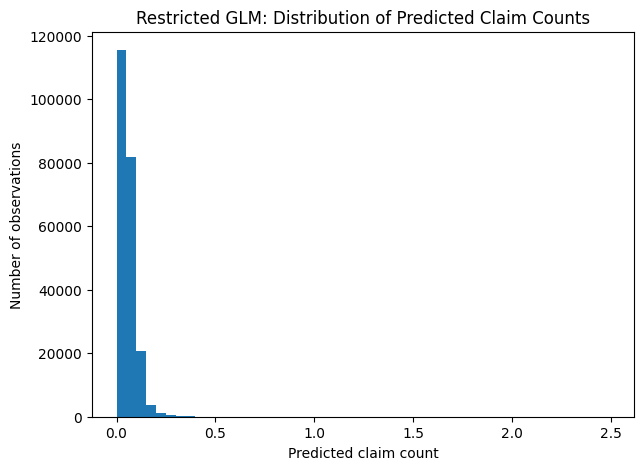

In [ ]:
# =========================
# 8. Restricted Poisson GLM
# =========================

# Safety check: exposure must be strictly positive for log-offset
if (df_pricing_train[exposure_main] <= 0).any() or (df_pricing_test[exposure_main] <= 0).any():
    raise ValueError("Exposure contains non-positive values. A log-offset requires Exposure > 0.")

# Restricted GLM formula
restricted_formula = (
    "ClaimNb ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus"
)

# Fit restricted Poisson GLM with log(Exposure) offset
restricted_glm = smf.glm(
    formula=restricted_formula,
    data=df_pricing_train,
    family=sm.families.Poisson(),
    offset=np.log(df_pricing_train[exposure_main])
).fit()

print(restricted_glm.summary())

# =========================
# 9. Restricted GLM predictions and evaluation
# =========================

pred_restricted_count = restricted_glm.predict(
    df_pricing_test,
    offset=np.log(df_pricing_test[exposure_main])
)

actual_portfolio_freq = (
    df_pricing_test[target_main].sum() / df_pricing_test[exposure_main].sum()
)

predicted_portfolio_freq = (
    pred_restricted_count.sum() / df_pricing_test[exposure_main].sum()
)

restricted_results = pd.DataFrame({
    "model": ["Restricted GLM"],
    "mean_actual_claim_count": [df_pricing_test[target_main].mean()],
    "mean_predicted_claim_count": [pred_restricted_count.mean()],
    "actual_portfolio_claim_frequency": [actual_portfolio_freq],
    "predicted_portfolio_claim_frequency": [predicted_portfolio_freq],
    "poisson_deviance": [
        sk.metrics.mean_poisson_deviance(
            df_pricing_test[target_main],
            pred_restricted_count
        )
    ],
    "mae_count": [
        sk.metrics.mean_absolute_error(
            df_pricing_test[target_main],
            pred_restricted_count
        )
    ]
})

print("\nRestricted GLM results")
print(restricted_results)

# =========================
# 11. Coefficient table
# =========================

restricted_coef_table = pd.DataFrame({
    "term": restricted_glm.params.index,
    "coefficient": restricted_glm.params.values
})

restricted_coef_table["abs_coefficient"] = restricted_coef_table["coefficient"].abs()

top_restricted_terms = (
    restricted_coef_table
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
    .drop(columns=["abs_coefficient"])
)

print("\nTop 15 coefficients (absolute value) - restricted GLM")
print(top_restricted_terms)

# =========================
# 12. Simple diagnostic plot
# =========================

plt.figure(figsize=(7, 5))
plt.hist(pred_restricted_count, bins=50)
plt.title("Restricted GLM: Distribution of Predicted Claim Counts")
plt.xlabel("Predicted claim count")
plt.ylabel("Number of observations")
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               454268
Model:                            GLM   Df Residuals:                   454216
Model Family:                 Poisson   Df Model:                           51
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -96099.
Date:                Sat, 16 May 2026   Deviance:                   1.4562e+05
Time:                        15:56:41   Pearson chi2:                 1.18e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01115
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

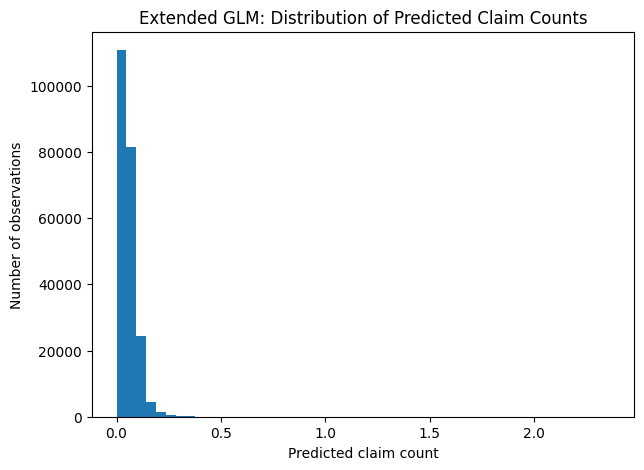


Restricted vs Extended GLM comparison
            model  mean_actual_claim_count  mean_predicted_claim_count  actual_portfolio_claim_frequency  \
0  Restricted GLM                 0.052949                    0.053397                          0.100158   
1    Extended GLM                 0.052949                    0.053376                          0.100158   

   predicted_portfolio_claim_frequency  poisson_deviance  mae_count  
0                             0.101005          0.319780   0.098717  
1                             0.100966          0.319496   0.098717  


In [ ]:
# =========================
# 13. Extended Poisson GLM
# =========================

extended_formula = (
    "ClaimNb ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus "
    "+ C(VehBrand) + C(VehGas) + Density + C(Region)"
)

extended_glm = smf.glm(
    formula=extended_formula,
    data=df_pricing_train,
    family=sm.families.Poisson(),
    offset=np.log(df_pricing_train[exposure_main])
).fit()

print(extended_glm.summary())

# =========================
# 14. Extended GLM predictions
# =========================

pred_extended_count = extended_glm.predict(
    df_pricing_test,
    offset=np.log(df_pricing_test[exposure_main])
)

actual_portfolio_freq_ext = (
    df_pricing_test[target_main].sum() / df_pricing_test[exposure_main].sum()
)

predicted_portfolio_freq_ext = (
    pred_extended_count.sum() / df_pricing_test[exposure_main].sum()
)

# =========================
# 15. Extended GLM evaluation
# =========================

extended_results = pd.DataFrame({
    "model": ["Extended GLM"],
    "mean_actual_claim_count": [df_pricing_test[target_main].mean()],
    "mean_predicted_claim_count": [pred_extended_count.mean()],
    "actual_portfolio_claim_frequency": [actual_portfolio_freq_ext],
    "predicted_portfolio_claim_frequency": [predicted_portfolio_freq_ext],
    "poisson_deviance": [
        sk.metrics.mean_poisson_deviance(
            df_pricing_test[target_main],
            pred_extended_count
        )
    ],
    "mae_count": [
        sk.metrics.mean_absolute_error(
            df_pricing_test[target_main],
            pred_extended_count
        )
    ]
})

print("\nExtended GLM results")
print(extended_results)

# =========================
# 16. Coefficient table
# =========================

extended_coef_table = pd.DataFrame({
    "term": extended_glm.params.index,
    "coefficient": extended_glm.params.values
})

extended_coef_table["abs_coefficient"] = extended_coef_table["coefficient"].abs()

top_extended_terms = (
    extended_coef_table
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
    .drop(columns=["abs_coefficient"])
)

print("\nTop 20 coefficients (absolute value) - extended GLM")
print(top_extended_terms)

# =========================
# 17. Histogram of predicted counts
# =========================

plt.figure(figsize=(7, 5))
plt.hist(pred_extended_count, bins=50)
plt.title("Extended GLM: Distribution of Predicted Claim Counts")
plt.xlabel("Predicted claim count")
plt.ylabel("Number of observations")
plt.show()

# =========================
# 18. Compare restricted vs extended GLM
# =========================

glm_comparison = pd.concat([restricted_results, extended_results], ignore_index=True)

print("\nRestricted vs Extended GLM comparison")
print(glm_comparison)

Boosting train shape: (454268, 56)
Boosting test shape: (223745, 56)

Boosting results
                model  mean_actual_claim_count  mean_predicted_claim_count  actual_portfolio_claim_frequency  \
0  Boosting (XGBoost)                 0.052949                    0.053352                          0.100158   

   predicted_portfolio_claim_frequency  poisson_deviance  mae_count  
0                              0.10092          0.304294   0.096568  


<Figure size 800x600 with 0 Axes>

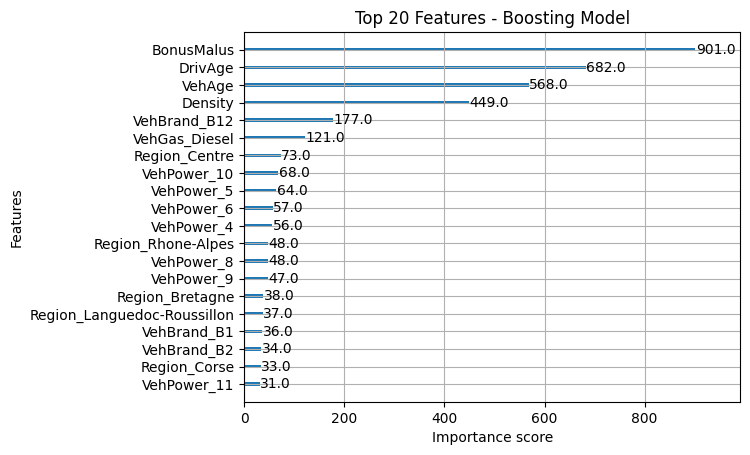


Preliminary pricing benchmark comparison
                model  mean_actual_claim_count  mean_predicted_claim_count  actual_portfolio_claim_frequency  \
0      Restricted GLM                 0.052949                    0.053397                          0.100158   
1        Extended GLM                 0.052949                    0.053376                          0.100158   
2  Boosting (XGBoost)                 0.052949                    0.053352                          0.100158   

   predicted_portfolio_claim_frequency  poisson_deviance  mae_count  
0                             0.101005          0.319780   0.098717  
1                             0.100966          0.319496   0.098717  
2                             0.100920          0.304294   0.096568  


In [ ]:
# =========================
# 19. Prepare data for boosting model
# =========================

boosting_vars = extended_vars.copy()

X_train_boost = df_pricing_train[boosting_vars].copy()
X_test_boost = df_pricing_test[boosting_vars].copy()

y_train_boost = df_pricing_train[target_main].copy()
y_test_boost = df_pricing_test[target_main].copy()

exposure_train_boost = df_pricing_train[exposure_main].copy()
exposure_test_boost = df_pricing_test[exposure_main].copy()

# One-hot encode categorical variables on training data only
X_train_boost_enc, X_test_boost_enc, encoder_boost, boost_cat_cols, boost_num_cols = encode_train_test(
    X_train_boost,
    X_test_boost
)

print("Boosting train shape:", X_train_boost_enc.shape)
print("Boosting test shape:", X_test_boost_enc.shape)

# =========================
# 20. XGBoost frequency model
# =========================

# Model annualized claim frequency = ClaimNb / Exposure
# and use Exposure as sample weight
freq_train_boost = y_train_boost / exposure_train_boost

xgb_freq = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED
)

xgb_freq.fit(
    X_train_boost_enc,
    freq_train_boost,
    sample_weight=exposure_train_boost
)

# Predict annualized claim frequency
pred_boost_freq = xgb_freq.predict(X_test_boost_enc)

# Avoid negative predictions for frequency
pred_boost_freq = np.clip(pred_boost_freq, a_min=0, a_max=None)

# Convert frequency prediction back to claim count prediction
pred_boost_count = pred_boost_freq * exposure_test_boost

# For Poisson deviance only: predictions must be strictly positive
EPS = 1e-10
pred_boost_count_dev = np.clip(pred_boost_count, a_min=EPS, a_max=None)

# =========================
# 21. Boosting evaluation
# =========================

actual_portfolio_freq_boost = (
    y_test_boost.sum() / exposure_test_boost.sum()
)

predicted_portfolio_freq_boost = (
    pred_boost_count.sum() / exposure_test_boost.sum()
)

boosting_results = pd.DataFrame({
    "model": ["Boosting (XGBoost)"],
    "mean_actual_claim_count": [y_test_boost.mean()],
    "mean_predicted_claim_count": [pred_boost_count.mean()],
    "actual_portfolio_claim_frequency": [actual_portfolio_freq_boost],
    "predicted_portfolio_claim_frequency": [predicted_portfolio_freq_boost],
    "poisson_deviance": [
        sk.metrics.mean_poisson_deviance(
            y_test_boost,
            pred_boost_count_dev
        )
    ],
    "mae_count": [
        sk.metrics.mean_absolute_error(
            y_test_boost,
            pred_boost_count
        )
    ]
})

print("\nBoosting results")
print(boosting_results)

# =========================
# 22. Feature importance
# =========================

plt.figure(figsize=(8, 6))
plot_importance(xgb_freq, max_num_features=20)
plt.title("Top 20 Features - Boosting Model")
plt.show()

# =========================
# 23. Final main model comparison
# =========================

main_model_comparison = pd.concat(
    [restricted_results, extended_results, boosting_results],
    ignore_index=True
)

print("\nPreliminary pricing benchmark comparison")
print(main_model_comparison)

In [ ]:
# =========================
# PART B. Main thesis experiment: enriched fairness setting
# Restricted GLM, Extended GLM, and Boosting
# Best-estimate, Unawareness, and Aware schemes
# =========================

# =========================
# 24. Fairness-use-case setup
# =========================
# Terminology used in the thesis
D_col = "SexVP"         # synthetic protected variable
y_col = "ClaimsVP"      # synthetic binary target
w_col = "Exposure"      # exposure used as sample weight

# Use df_model from the enriched dataset
fairness_feature_cols = [col for col in df_model.columns if col not in [y_col, w_col]]

X_fair_all = df_model[fairness_feature_cols].copy()
y_fair_all = df_model[y_col].copy()
w_fair_all = df_model[w_col].copy()

print("Protected variable:", D_col)
print("Fairness target:", y_col)
print("Weight variable:", w_col)
print("Fairness features:")
print(fairness_feature_cols)

# =========================
# 25. One shared split for the fairness-use-case branch
# =========================

fair_train_idx, fair_test_idx = train_test_split(
    df_model.index,
    test_size=0.33,
    random_state=SEED,
    stratify=y_fair_all
)

df_fair_train = df_model.loc[fair_train_idx].copy()
df_fair_test = df_model.loc[fair_test_idx].copy()

X_train_fair_all = df_fair_train[fairness_feature_cols].copy()
X_test_fair_all = df_fair_test[fairness_feature_cols].copy()

y_train_fair = df_fair_train[y_col].copy()
y_test_fair = df_fair_test[y_col].copy()

w_train_fair = df_fair_train[w_col].copy()
w_test_fair = df_fair_test[w_col].copy()

print("\nFairness train shape:", X_train_fair_all.shape)
print("Fairness test shape:", X_test_fair_all.shape)

print("\nTarget distribution in fairness training set:")
print(y_train_fair.value_counts(normalize=True))

print("\nTarget distribution in fairness test set:")
print(y_test_fair.value_counts(normalize=True))

# =========================
# 26. Define pricing schemes for the fairness use case
# =========================

# Best-estimate scheme: include the protected variable
X_train_best_estimate = X_train_fair_all.copy()
X_test_best_estimate = X_test_fair_all.copy()

# Unawareness scheme: exclude the protected variable
X_train_unawareness = X_train_fair_all.drop(columns=[D_col]).copy()
X_test_unawareness = X_test_fair_all.drop(columns=[D_col]).copy()

# Empirical protected-group share in training data
prop_D1_train = X_train_best_estimate[D_col].mean()
prop_D0_train = 1 - prop_D1_train

print("\nProtected-group share in fairness training data:")
print(f"P({D_col}=1): {prop_D1_train:.4f}")
print(f"P({D_col}=0): {prop_D0_train:.4f}")

print("\nBest-estimate columns:")
print(X_train_best_estimate.columns.tolist())

print("\nUnawareness columns:")
print(X_train_unawareness.columns.tolist())

# =========================
# 27. Train-only one-hot encoding for fairness branch
# =========================

X_train_best_estimate_enc, X_test_best_estimate_enc, encoder_best_estimate, be_cat_cols, be_num_cols = encode_train_test(
    X_train_best_estimate,
    X_test_best_estimate
)

X_train_unawareness_enc, X_test_unawareness_enc, encoder_unawareness, unaw_cat_cols, unaw_num_cols = encode_train_test(
    X_train_unawareness,
    X_test_unawareness
)

print("\nEncoded best-estimate training shape:", X_train_best_estimate_enc.shape)
print("Encoded best-estimate test shape:", X_test_best_estimate_enc.shape)

print("\nEncoded unawareness training shape:", X_train_unawareness_enc.shape)
print("Encoded unawareness test shape:", X_test_unawareness_enc.shape)

# =========================
# 28. Proxy-detectability dataset
# =========================

# Proxy-detectability asks:
# can the protected variable be inferred from allowed variables only?

y_train_proxy = X_train_best_estimate[D_col].copy()
y_test_proxy = X_test_best_estimate[D_col].copy()

# By construction, proxy features are identical to the unawareness feature set
X_train_proxy_enc = X_train_unawareness_enc.copy()
X_test_proxy_enc = X_test_unawareness_enc.copy()

print("\nProxy train shape:", X_train_proxy_enc.shape)
print("Proxy test shape:", X_test_proxy_enc.shape)

print("\nProxy target distribution in training set:")
print(y_train_proxy.value_counts(normalize=True))

print("\nProxy target distribution in test set:")
print(y_test_proxy.value_counts(normalize=True))

Protected variable: SexVP
Fairness target: ClaimsVP
Weight variable: Exposure
Fairness features:
['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region', 'SexVP']

Fairness train shape: (454268, 10)
Fairness test shape: (223745, 10)

Target distribution in fairness training set:
ClaimsVP
0    0.927593
1    0.072407
Name: proportion, dtype: float64

Target distribution in fairness test set:
ClaimsVP
0    0.927592
1    0.072408
Name: proportion, dtype: float64

Protected-group share in fairness training data:
P(SexVP=1): 0.5262
P(SexVP=0): 0.4738

Best-estimate columns:
['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region', 'SexVP']

Unawareness columns:
['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Area', 'Density', 'Region']

Encoded best-estimate training shape: (454268, 57)
Encoded best-estimate test shape: (223745, 57)

Encoded unawareness training shape: (454268, 56)
Encod


Core metric: Proxy-detectability results
      model                                               task  accuracy       auc  log_loss  brier_score
0  Boosting  Proxy-detectability: predict SexVP from non-se...  0.582047  0.606733  0.671622     0.239498

Saved file: proxy_results.csv


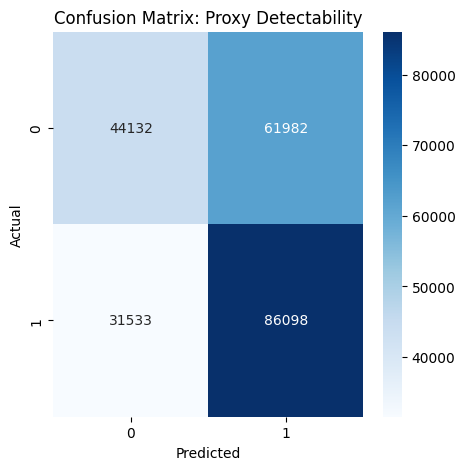

<Figure size 800x600 with 0 Axes>

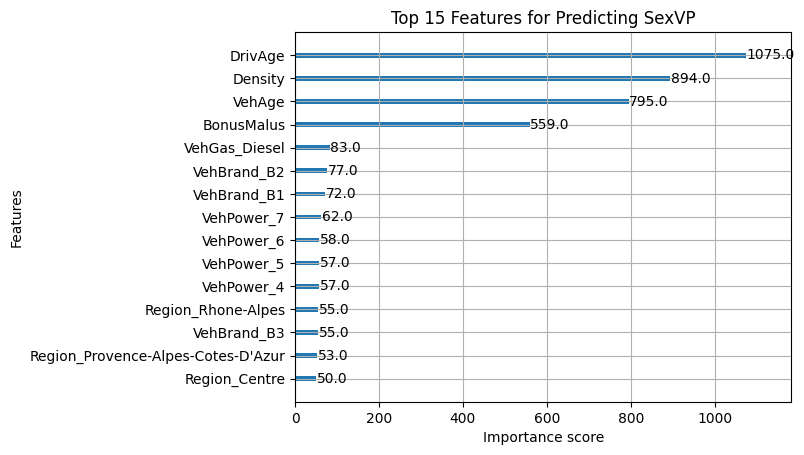

In [ ]:
# =========================
# 29. Proxy-detectability model
# =========================

proxy_xgb = xgb.XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    tree_method="hist"
)

proxy_xgb.fit(X_train_proxy_enc, y_train_proxy)

# Predictions
proxy_pred_class = proxy_xgb.predict(X_test_proxy_enc)
proxy_pred_prob = proxy_xgb.predict_proba(X_test_proxy_enc)[:, 1]

# Evaluation
proxy_results = pd.DataFrame({
    "model": ["Boosting"],
    "task": ["Proxy-detectability: predict SexVP from non-sensitive variables"],
    "accuracy": [accuracy_score(y_test_proxy, proxy_pred_class)],
    "auc": [roc_auc_score(y_test_proxy, proxy_pred_prob)],
    "log_loss": [log_loss(y_test_proxy, proxy_pred_prob)],
    "brier_score": [brier_score_loss(y_test_proxy, proxy_pred_prob)]
})

print("\nCore metric: Proxy-detectability results")
print(proxy_results)

proxy_results_rounded = proxy_results.copy()
numeric_cols = proxy_results_rounded.select_dtypes(include=[np.number]).columns
proxy_results_rounded[numeric_cols] = proxy_results_rounded[numeric_cols].round(4)

proxy_results_rounded.to_csv("proxy_results.csv", index=False)
print("\nSaved file: proxy_results.csv")

# Confusion matrix
cm_proxy = confusion_matrix(y_test_proxy, proxy_pred_class)

plt.figure(figsize=(5, 5))
sns.heatmap(cm_proxy, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Proxy Detectability")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# Feature importance
plt.figure(figsize=(8, 6))
plot_importance(proxy_xgb, max_num_features=15)
plt.title("Top 15 Features for Predicting SexVP")
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:               ClaimsVP   No. Observations:               454268
Model:                            GLM   Df Residuals:                240129.85
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67708.
Date:                Sat, 16 May 2026   Deviance:                   1.3542e+05
Time:                        15:57:32   Pearson chi2:                 2.40e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.003933
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -4.1735      0.05

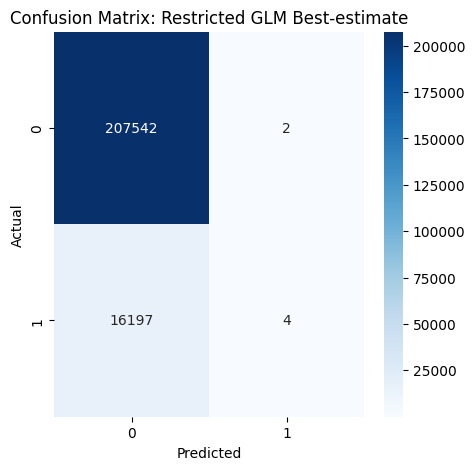


Top 20 coefficients - Restricted GLM Best-estimate
                 term  coefficient
0           Intercept    -4.173462
14  C(VehPower)[T.13]     0.715285
15  C(VehPower)[T.14]     0.645054
10   C(VehPower)[T.9]     0.410498
12  C(VehPower)[T.11]     0.407690
11  C(VehPower)[T.10]     0.384706
13  C(VehPower)[T.12]     0.340887
20              SexVP     0.257544
16  C(VehPower)[T.15]    -0.192701
7    C(VehPower)[T.6]     0.161995
6    C(VehPower)[T.5]     0.142913
8    C(VehPower)[T.7]     0.115901
4        C(Area)[T.E]     0.080575
3        C(Area)[T.D]     0.058039
9    C(VehPower)[T.8]     0.047609
2        C(Area)[T.C]     0.045378
1        C(Area)[T.B]    -0.031696
19         BonusMalus     0.017886
17             VehAge    -0.016045
18            DrivAge     0.010661

Group summary - Restricted GLM Best-estimate
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.076132  106114
1      1           0.080064            

In [ ]:
# =========================
# PART C. Core thesis outputs
# Core fairness metrics, scheme gaps, and proxy-detectability
# =========================

# =========================
# 30A. Restricted GLM fairness branch: best-estimate
# =========================

restricted_fair_formula_best_estimate = (
    "ClaimsVP ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus + SexVP"
)

# Exposure is used as a frequency weight to account for unequal policy durations
# in the enriched binary fairness setting.

restricted_best_estimate_glm = smf.glm(
    formula=restricted_fair_formula_best_estimate,
    data=df_fair_train,
    family=sm.families.Binomial(),
    freq_weights=w_train_fair
).fit()

print(restricted_best_estimate_glm.summary())

# Predicted probabilities and binary predictions
pred_restricted_best_estimate_prob = restricted_best_estimate_glm.predict(df_fair_test)

restricted_best_estimate_metrics, pred_restricted_best_estimate_class = summarize_binary_predictions(
    y_test_fair,
    pred_restricted_best_estimate_prob,
    threshold=THRESHOLD
)

print("\nRestricted GLM best-estimate results")
for k, v in restricted_best_estimate_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_restricted_best_estimate_class,
    "Confusion Matrix: Restricted GLM Best-estimate"
)

# =========================
# 30B. Restricted GLM coefficient table
# =========================

restricted_best_estimate_coef_table = pd.DataFrame({
    "term": restricted_best_estimate_glm.params.index,
    "coefficient": restricted_best_estimate_glm.params.values
})

restricted_best_estimate_coef_table["abs_coefficient"] = (
    restricted_best_estimate_coef_table["coefficient"].abs()
)

top_restricted_best_estimate_terms = (
    restricted_best_estimate_coef_table
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
    .drop(columns=["abs_coefficient"])
)

print("\nTop 20 coefficients - Restricted GLM Best-estimate")
print(top_restricted_best_estimate_terms)

# =========================
# 30C. Restricted GLM group summary
# =========================

restricted_best_estimate_group_summary = pd.DataFrame({
    "SexVP": df_fair_test[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_restricted_best_estimate_prob": pred_restricted_best_estimate_prob
})

group_summary_restricted_best_estimate = (
    restricted_best_estimate_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_restricted_best_estimate_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Restricted GLM Best-estimate")
print(group_summary_restricted_best_estimate)

# =========================
# 30D. Restricted GLM results table
# =========================

restricted_best_estimate_results = pd.DataFrame({
    "model": ["Restricted GLM"],
    "scheme": ["Best-estimate"],
    "accuracy": [restricted_best_estimate_metrics["accuracy"]],
    "auc": [restricted_best_estimate_metrics["auc"]],
    "log_loss": [restricted_best_estimate_metrics["log_loss"]],
    "brier_score": [restricted_best_estimate_metrics["brier_score"]],
    "mean_prediction": [restricted_best_estimate_metrics["mean_prediction"]]
})

print("\nRestricted GLM Best-estimate summary table")
print(restricted_best_estimate_results)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               ClaimsVP   No. Observations:               454268
Model:                            GLM   Df Residuals:                240130.85
Model Family:                Binomial   Df Model:                           19
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67850.
Date:                Sat, 16 May 2026   Deviance:                   1.3570e+05
Time:                        15:57:41   Pearson chi2:                 2.40e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.003311
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.9963      0.05

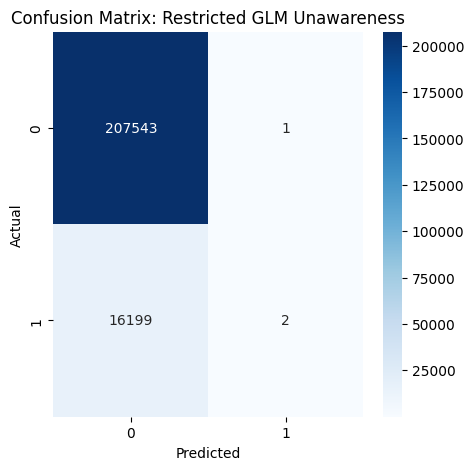


Top 20 coefficients - Restricted GLM Unawareness
                 term  coefficient
0           Intercept    -3.996305
14  C(VehPower)[T.13]     0.599594
15  C(VehPower)[T.14]     0.514502
10   C(VehPower)[T.9]     0.345899
16  C(VehPower)[T.15]    -0.339474
12  C(VehPower)[T.11]     0.317794
11  C(VehPower)[T.10]     0.306505
13  C(VehPower)[T.12]     0.236515
7    C(VehPower)[T.6]     0.136997
6    C(VehPower)[T.5]     0.129512
4        C(Area)[T.E]     0.080846
8    C(VehPower)[T.7]     0.077103
3        C(Area)[T.D]     0.057091
2        C(Area)[T.C]     0.045718
1        C(Area)[T.B]    -0.029940
19         BonusMalus     0.017844
17             VehAge    -0.016063
18            DrivAge     0.010635
9    C(VehPower)[T.8]    -0.002573
5        C(Area)[T.F]     0.001311

Group summary - Restricted GLM Unawareness
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.086058  106114
1      1           0.080064                

In [ ]:
# =========================
# 30E. Restricted GLM fairness branch: unawareness
# =========================

restricted_fair_formula_unawareness = (
    "ClaimsVP ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus"
)

restricted_unawareness_glm = smf.glm(
    formula=restricted_fair_formula_unawareness,
    data=df_fair_train,
    family=sm.families.Binomial(),
    freq_weights=w_train_fair
).fit()

print(restricted_unawareness_glm.summary())

# Predicted probabilities and binary predictions
pred_restricted_unawareness_prob = restricted_unawareness_glm.predict(df_fair_test)

restricted_unawareness_metrics, pred_restricted_unawareness_class = summarize_binary_predictions(
    y_test_fair,
    pred_restricted_unawareness_prob,
    threshold=THRESHOLD
)

print("\nRestricted GLM unawareness results")
for k, v in restricted_unawareness_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_restricted_unawareness_class,
    "Confusion Matrix: Restricted GLM Unawareness"
)

# =========================
# 30F. Restricted GLM unawareness coefficient table
# =========================

restricted_unawareness_coef_table = pd.DataFrame({
    "term": restricted_unawareness_glm.params.index,
    "coefficient": restricted_unawareness_glm.params.values
})

restricted_unawareness_coef_table["abs_coefficient"] = (
    restricted_unawareness_coef_table["coefficient"].abs()
)

top_restricted_unawareness_terms = (
    restricted_unawareness_coef_table
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
    .drop(columns=["abs_coefficient"])
)

print("\nTop 20 coefficients - Restricted GLM Unawareness")
print(top_restricted_unawareness_terms)

# =========================
# 30G. Restricted GLM unawareness group summary
# =========================

restricted_unawareness_group_summary = pd.DataFrame({
    "SexVP": df_fair_test[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_restricted_unawareness_prob": pred_restricted_unawareness_prob
})

group_summary_restricted_unawareness = (
    restricted_unawareness_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_restricted_unawareness_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Restricted GLM Unawareness")
print(group_summary_restricted_unawareness)

# =========================
# 30H. Restricted GLM unawareness results table
# =========================

restricted_unawareness_results = pd.DataFrame({
    "model": ["Restricted GLM"],
    "scheme": ["Unawareness"],
    "accuracy": [restricted_unawareness_metrics["accuracy"]],
    "auc": [restricted_unawareness_metrics["auc"]],
    "log_loss": [restricted_unawareness_metrics["log_loss"]],
    "brier_score": [restricted_unawareness_metrics["brier_score"]],
    "mean_prediction": [restricted_unawareness_metrics["mean_prediction"]]
})

print("\nRestricted GLM Unawareness summary table")
print(restricted_unawareness_results)

# =========================
# 30I. Restricted GLM scheme comparison
# =========================

restricted_glm_scheme_comparison = pd.concat(
    [restricted_best_estimate_results, restricted_unawareness_results],
    ignore_index=True
)

print("\nRestricted GLM: Best-estimate vs Unawareness")
print(restricted_glm_scheme_comparison)


Restricted GLM Aware results
accuracy: 0.9276
auc: 0.5631
log_loss: 0.2592
brier_score: 0.0671
mean_prediction: 0.0855


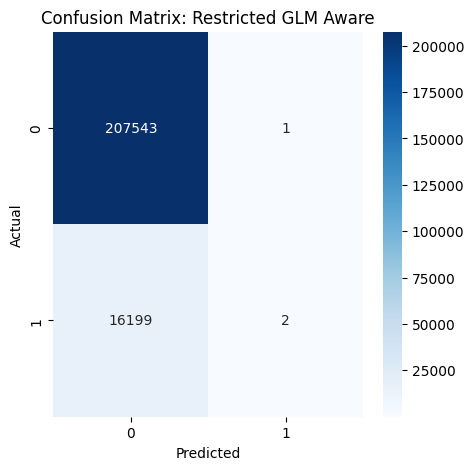


Group summary - Restricted GLM Aware
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.086670  106114
1      1           0.080064                    0.084372  117631

Restricted GLM Aware summary table
            model scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Restricted GLM  Aware  0.927596  0.563058  0.259161     0.067111         0.085462

Restricted GLM: Best-estimate vs Unawareness vs Aware
            model         scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Restricted GLM  Best-estimate  0.927601  0.574597  0.258529     0.067027         0.085333
1  Restricted GLM    Unawareness  0.927596  0.563627  0.259078     0.067094         0.085328
2  Restricted GLM          Aware  0.927596  0.563058  0.259161     0.067111         0.085462

Scheme-gap table - Restricted GLM
            model                   comparison  mean_signed_gap  mean_absolute_gap  mean_gap_group0  m

In [ ]:
# =========================
# 30J. Restricted GLM fairness branch: Aware
# =========================

# Counterfactual copies of the restricted best-estimate test data
df_fair_test_cf_0 = df_fair_test.copy()
df_fair_test_cf_1 = df_fair_test.copy()

# Set protected variable to each possible value
df_fair_test_cf_0[D_col] = 0
df_fair_test_cf_1[D_col] = 1

# Predict under both counterfactual protected-group assignments
pred_restricted_cf_0_prob = restricted_best_estimate_glm.predict(df_fair_test_cf_0)
pred_restricted_cf_1_prob = restricted_best_estimate_glm.predict(df_fair_test_cf_1)

# Average over empirical protected-group distribution in training data
pred_restricted_aware_prob = (
    prop_D0_train * pred_restricted_cf_0_prob
    + prop_D1_train * pred_restricted_cf_1_prob
)

restricted_aware_metrics, pred_restricted_aware_class = summarize_binary_predictions(
    y_test_fair,
    pred_restricted_aware_prob,
    threshold=THRESHOLD
)

print("\nRestricted GLM Aware results")
for k, v in restricted_aware_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_restricted_aware_class,
    "Confusion Matrix: Restricted GLM Aware"
)

# =========================
# 30K. Restricted GLM Aware group summary
# =========================

restricted_aware_group_summary = pd.DataFrame({
    "SexVP": df_fair_test[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_restricted_aware_prob": pred_restricted_aware_prob
})

group_summary_restricted_aware = (
    restricted_aware_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_restricted_aware_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Restricted GLM Aware")
print(group_summary_restricted_aware)

# =========================
# 30L. Restricted GLM Aware results table
# =========================

restricted_aware_results = pd.DataFrame({
    "model": ["Restricted GLM"],
    "scheme": ["Aware"],
    "accuracy": [restricted_aware_metrics["accuracy"]],
    "auc": [restricted_aware_metrics["auc"]],
    "log_loss": [restricted_aware_metrics["log_loss"]],
    "brier_score": [restricted_aware_metrics["brier_score"]],
    "mean_prediction": [restricted_aware_metrics["mean_prediction"]]
})

print("\nRestricted GLM Aware summary table")
print(restricted_aware_results)

# =========================
# 30M. Compare all three restricted GLM schemes
# =========================

restricted_glm_three_scheme_comparison = pd.concat(
    [
        restricted_best_estimate_results,
        restricted_unawareness_results,
        restricted_aware_results
    ],
    ignore_index=True
)

print("\nRestricted GLM: Best-estimate vs Unawareness vs Aware")
print(restricted_glm_three_scheme_comparison)

restricted_gap_table = compute_scheme_gap_table(
    pred_dict={
        "Best-estimate": pred_restricted_best_estimate_prob,
        "Unawareness": pred_restricted_unawareness_prob,
        "Aware": pred_restricted_aware_prob
    },
    sensitive_series=df_fair_test[D_col],
    model_name="Restricted GLM"
)

print("\nScheme-gap table - Restricted GLM")
print(restricted_gap_table)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               ClaimsVP   No. Observations:               454268
Model:                            GLM   Df Residuals:                240097.85
Model Family:                Binomial   Df Model:                           52
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67542.
Date:                Sat, 16 May 2026   Deviance:                   1.3508e+05
Time:                        15:58:12   Pearson chi2:                 2.40e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.004662
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

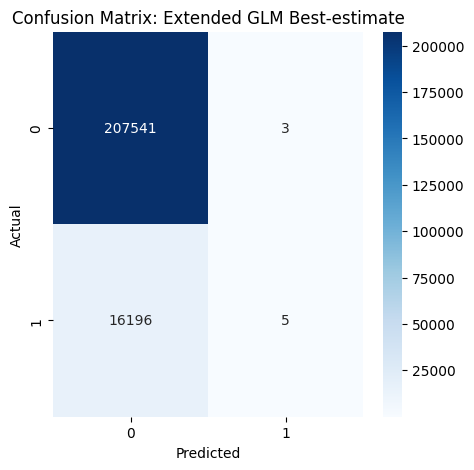


Top 25 coefficients - Extended GLM Best-estimate
                                 term  coefficient
0                           Intercept    -4.173422
14                  C(VehPower)[T.13]     0.687375
15                  C(VehPower)[T.14]     0.630656
12                  C(VehPower)[T.11]     0.440518
11                  C(VehPower)[T.10]     0.415044
10                   C(VehPower)[T.9]     0.407861
13                  C(VehPower)[T.12]     0.394620
36         C(Region)[T.Franche-Comte]    -0.346212
52                              SexVP     0.257799
41         C(Region)[T.Midi-Pyrenees]    -0.220281
32              C(Region)[T.Bretagne]     0.216154
37       C(Region)[T.Haute-Normandie]    -0.204616
19                 C(VehBrand)[T.B12]    -0.189248
40              C(Region)[T.Limousin]     0.173919
33                C(Region)[T.Centre]     0.147003
4                        C(Area)[T.E]     0.145828
29              C(Region)[T.Auvergne]    -0.143931
16                  C(VehPower)[

In [ ]:
# =========================
# 31A. Extended GLM fairness branch: best-estimate
# =========================

extended_fair_formula_best_estimate = (
    "ClaimsVP ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus "
    "+ C(VehBrand) + C(VehGas) + Density + C(Region) + SexVP"
)

extended_best_estimate_glm = smf.glm(
    formula=extended_fair_formula_best_estimate,
    data=df_fair_train,
    family=sm.families.Binomial(),
    freq_weights=w_train_fair
).fit()

print(extended_best_estimate_glm.summary())

# Predicted probabilities and binary predictions
pred_extended_best_estimate_prob = extended_best_estimate_glm.predict(df_fair_test)

extended_best_estimate_metrics, pred_extended_best_estimate_class = summarize_binary_predictions(
    y_test_fair,
    pred_extended_best_estimate_prob,
    threshold=THRESHOLD
)

print("\nExtended GLM best-estimate results")
for k, v in extended_best_estimate_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_extended_best_estimate_class,
    "Confusion Matrix: Extended GLM Best-estimate"
)

# =========================
# 31B. Extended GLM coefficient table
# =========================

extended_best_estimate_coef_table = pd.DataFrame({
    "term": extended_best_estimate_glm.params.index,
    "coefficient": extended_best_estimate_glm.params.values
})

extended_best_estimate_coef_table["abs_coefficient"] = (
    extended_best_estimate_coef_table["coefficient"].abs()
)

top_extended_best_estimate_terms = (
    extended_best_estimate_coef_table
    .sort_values("abs_coefficient", ascending=False)
    .head(25)
    .drop(columns=["abs_coefficient"])
)

print("\nTop 25 coefficients - Extended GLM Best-estimate")
print(top_extended_best_estimate_terms)

# =========================
# 31C. Extended GLM group summary
# =========================

extended_best_estimate_group_summary = pd.DataFrame({
    "SexVP": df_fair_test[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_extended_best_estimate_prob": pred_extended_best_estimate_prob
})

group_summary_extended_best_estimate = (
    extended_best_estimate_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_extended_best_estimate_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Extended GLM Best-estimate")
print(group_summary_extended_best_estimate)

# =========================
# 31D. Extended GLM results table
# =========================

extended_best_estimate_results = pd.DataFrame({
    "model": ["Extended GLM"],
    "scheme": ["Best-estimate"],
    "accuracy": [extended_best_estimate_metrics["accuracy"]],
    "auc": [extended_best_estimate_metrics["auc"]],
    "log_loss": [extended_best_estimate_metrics["log_loss"]],
    "brier_score": [extended_best_estimate_metrics["brier_score"]],
    "mean_prediction": [extended_best_estimate_metrics["mean_prediction"]]
})

print("\nExtended GLM Best-estimate summary table")
print(extended_best_estimate_results)

                 Generalized Linear Model Regression Results                  
Dep. Variable:               ClaimsVP   No. Observations:               454268
Model:                            GLM   Df Residuals:                240098.85
Model Family:                Binomial   Df Model:                           51
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67683.
Date:                Sat, 16 May 2026   Deviance:                   1.3537e+05
Time:                        15:58:38   Pearson chi2:                 2.41e+05
No. Iterations:                     6   Pseudo R-squ. (CS):           0.004041
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

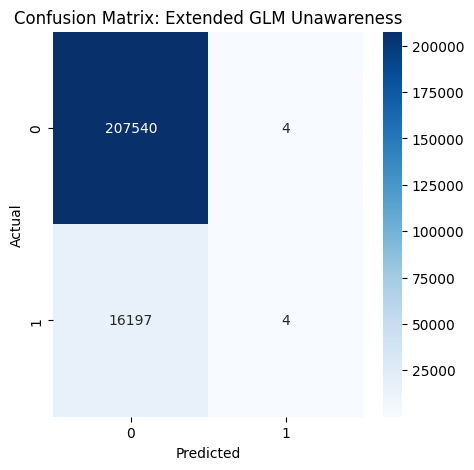


Top 25 coefficients - Extended GLM Unawareness
                                 term  coefficient
0                           Intercept    -3.999008
14                  C(VehPower)[T.13]     0.571946
15                  C(VehPower)[T.14]     0.499511
12                  C(VehPower)[T.11]     0.350559
10                   C(VehPower)[T.9]     0.343296
11                  C(VehPower)[T.10]     0.337356
36         C(Region)[T.Franche-Comte]    -0.336820
13                  C(VehPower)[T.12]     0.290763
16                  C(VehPower)[T.15]    -0.285415
32              C(Region)[T.Bretagne]     0.219599
41         C(Region)[T.Midi-Pyrenees]    -0.215615
37       C(Region)[T.Haute-Normandie]    -0.203099
19                 C(VehBrand)[T.B12]    -0.189894
40              C(Region)[T.Limousin]     0.180324
33                C(Region)[T.Centre]     0.149405
4                        C(Area)[T.E]     0.144717
29              C(Region)[T.Auvergne]    -0.141190
39  C(Region)[T.Languedoc-Roussill

In [ ]:
# =========================
# 31E. Extended GLM fairness branch: unawareness
# =========================

extended_fair_formula_unawareness = (
    "ClaimsVP ~ C(Area) + C(VehPower) + VehAge + DrivAge + BonusMalus "
    "+ C(VehBrand) + C(VehGas) + Density + C(Region)"
)

extended_unawareness_glm = smf.glm(
    formula=extended_fair_formula_unawareness,
    data=df_fair_train,
    family=sm.families.Binomial(),
    freq_weights=w_train_fair
).fit()

print(extended_unawareness_glm.summary())

# Predicted probabilities and binary predictions
pred_extended_unawareness_prob = extended_unawareness_glm.predict(df_fair_test)

extended_unawareness_metrics, pred_extended_unawareness_class = summarize_binary_predictions(
    y_test_fair,
    pred_extended_unawareness_prob,
    threshold=THRESHOLD
)

print("\nExtended GLM unawareness results")
for k, v in extended_unawareness_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_extended_unawareness_class,
    "Confusion Matrix: Extended GLM Unawareness"
)

# =========================
# 31F. Extended GLM unawareness coefficient table
# =========================

extended_unawareness_coef_table = pd.DataFrame({
    "term": extended_unawareness_glm.params.index,
    "coefficient": extended_unawareness_glm.params.values
})

extended_unawareness_coef_table["abs_coefficient"] = (
    extended_unawareness_coef_table["coefficient"].abs()
)

top_extended_unawareness_terms = (
    extended_unawareness_coef_table
    .sort_values("abs_coefficient", ascending=False)
    .head(25)
    .drop(columns=["abs_coefficient"])
)

print("\nTop 25 coefficients - Extended GLM Unawareness")
print(top_extended_unawareness_terms)

# =========================
# 31G. Extended GLM unawareness group summary
# =========================

extended_unawareness_group_summary = pd.DataFrame({
    "SexVP": df_fair_test[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_extended_unawareness_prob": pred_extended_unawareness_prob
})

group_summary_extended_unawareness = (
    extended_unawareness_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_extended_unawareness_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Extended GLM Unawareness")
print(group_summary_extended_unawareness)

# =========================
# 31H. Extended GLM unawareness results table
# =========================

extended_unawareness_results = pd.DataFrame({
    "model": ["Extended GLM"],
    "scheme": ["Unawareness"],
    "accuracy": [extended_unawareness_metrics["accuracy"]],
    "auc": [extended_unawareness_metrics["auc"]],
    "log_loss": [extended_unawareness_metrics["log_loss"]],
    "brier_score": [extended_unawareness_metrics["brier_score"]],
    "mean_prediction": [extended_unawareness_metrics["mean_prediction"]]
})

print("\nExtended GLM Unawareness summary table")
print(extended_unawareness_results)

# =========================
# 31I. Extended GLM scheme comparison
# =========================

extended_glm_scheme_comparison = pd.concat(
    [extended_best_estimate_results, extended_unawareness_results],
    ignore_index=True
)

print("\nExtended GLM: Best-estimate vs Unawareness")
print(extended_glm_scheme_comparison)


Extended GLM Aware results
accuracy: 0.9276
auc: 0.5680
log_loss: 0.2587
brier_score: 0.0670
mean_prediction: 0.0840


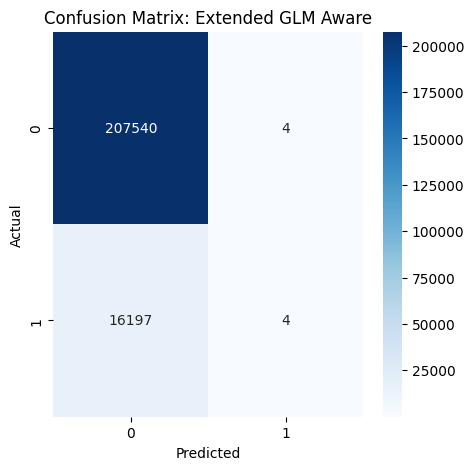


Group summary - Extended GLM Aware
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.085270  106114
1      1           0.080064                    0.082899  117631

Extended GLM Aware summary table
          model scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Extended GLM  Aware  0.927592  0.567972  0.258724      0.06705         0.084024

Extended GLM: Best-estimate vs Unawareness vs Aware
          model         scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Extended GLM  Best-estimate  0.927601  0.577910  0.258086     0.066966         0.083892
1  Extended GLM    Unawareness  0.927592  0.568358  0.258638     0.067032         0.083887
2  Extended GLM          Aware  0.927592  0.567972  0.258724     0.067050         0.084024

Scheme-gap table - Extended GLM
          model                   comparison  mean_signed_gap  mean_absolute_gap  mean_gap_group0  mean_gap_group1
0  Exte

In [ ]:
# =========================
# 31J. Extended GLM fairness branch: Aware
# =========================

# Counterfactual copies of the extended best-estimate test data
df_fair_test_ext_cf_0 = df_fair_test.copy()
df_fair_test_ext_cf_1 = df_fair_test.copy()

# Set protected variable to each possible value
df_fair_test_ext_cf_0[D_col] = 0
df_fair_test_ext_cf_1[D_col] = 1

# Predict under both counterfactual protected-group assignments
pred_extended_cf_0_prob = extended_best_estimate_glm.predict(df_fair_test_ext_cf_0)
pred_extended_cf_1_prob = extended_best_estimate_glm.predict(df_fair_test_ext_cf_1)

# Average over empirical protected-group distribution in training data
pred_extended_aware_prob = (
    prop_D0_train * pred_extended_cf_0_prob
    + prop_D1_train * pred_extended_cf_1_prob
)

extended_aware_metrics, pred_extended_aware_class = summarize_binary_predictions(
    y_test_fair,
    pred_extended_aware_prob,
    threshold=THRESHOLD
)

print("\nExtended GLM Aware results")
for k, v in extended_aware_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_extended_aware_class,
    "Confusion Matrix: Extended GLM Aware"
)

# =========================
# 31K. Extended GLM Aware group summary
# =========================

extended_aware_group_summary = pd.DataFrame({
    "SexVP": df_fair_test[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_extended_aware_prob": pred_extended_aware_prob
})

group_summary_extended_aware = (
    extended_aware_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_extended_aware_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Extended GLM Aware")
print(group_summary_extended_aware)

# =========================
# 31L. Extended GLM Aware results table
# =========================

extended_aware_results = pd.DataFrame({
    "model": ["Extended GLM"],
    "scheme": ["Aware"],
    "accuracy": [extended_aware_metrics["accuracy"]],
    "auc": [extended_aware_metrics["auc"]],
    "log_loss": [extended_aware_metrics["log_loss"]],
    "brier_score": [extended_aware_metrics["brier_score"]],
    "mean_prediction": [extended_aware_metrics["mean_prediction"]]
})

print("\nExtended GLM Aware summary table")
print(extended_aware_results)

# =========================
# 31M. Compare all three extended GLM schemes
# =========================

extended_glm_three_scheme_comparison = pd.concat(
    [
        extended_best_estimate_results,
        extended_unawareness_results,
        extended_aware_results
    ],
    ignore_index=True
)

print("\nExtended GLM: Best-estimate vs Unawareness vs Aware")
print(extended_glm_three_scheme_comparison)

extended_gap_table = compute_scheme_gap_table(
    pred_dict={
        "Best-estimate": pred_extended_best_estimate_prob,
        "Unawareness": pred_extended_unawareness_prob,
        "Aware": pred_extended_aware_prob
    },
    sensitive_series=df_fair_test[D_col],
    model_name="Extended GLM"
)

print("\nScheme-gap table - Extended GLM")
print(extended_gap_table)


Best-estimate Boosting results
accuracy: 0.9276
auc: 0.6166
log_loss: 0.2538
brier_score: 0.0661
mean_prediction: 0.0847


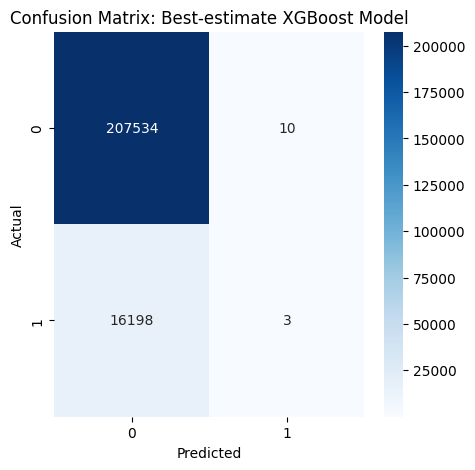

<Figure size 800x600 with 0 Axes>

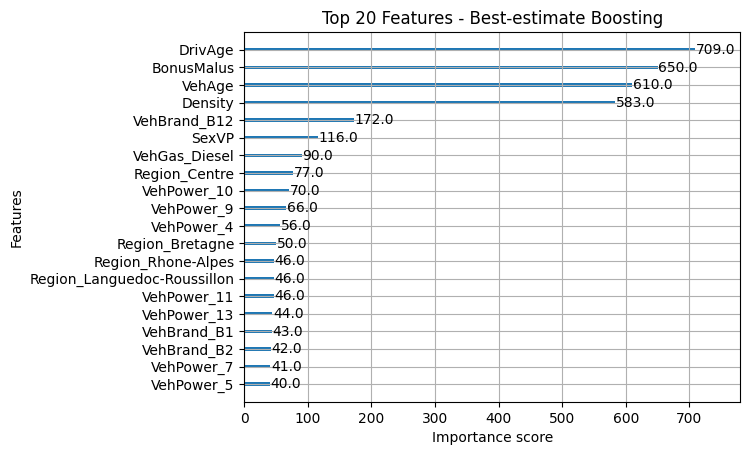


Group summary - best-estimate XGBoost model
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.076243  106114
1      1           0.080064                    0.092347  117631

Best-estimate XGBoost summary table
      model         scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Boosting  Best-estimate   0.92756  0.616634  0.253752     0.066138          0.08471


In [ ]:
# =========================
# 57. Best-estimate XGBoost model
# =========================

best_estimate_xgb = xgb.XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

best_estimate_xgb.fit(
    X_train_best_estimate_enc,
    y_train_fair,
    sample_weight=w_train_fair
)

# Predicted probabilities and binary predictions
pred_best_estimate_xgb_prob = best_estimate_xgb.predict_proba(X_test_best_estimate_enc)[:, 1]

best_estimate_xgb_metrics, pred_best_estimate_xgb_class = summarize_binary_predictions(
    y_test_fair,
    pred_best_estimate_xgb_prob,
    threshold=THRESHOLD
)

print("\nBest-estimate Boosting results")
for k, v in best_estimate_xgb_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_best_estimate_xgb_class,
    "Confusion Matrix: Best-estimate XGBoost Model"
)

# =========================
# 58. Feature importance
# =========================

plt.figure(figsize=(8, 6))
plot_importance(best_estimate_xgb, max_num_features=20)
plt.title("Top 20 Features - Best-estimate Boosting")
plt.show()

# =========================
# 59. Group-level predicted means by SexVP
# =========================

best_estimate_xgb_group_summary = pd.DataFrame({
    "SexVP": X_test_fair_all[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_best_estimate_xgb_prob": pred_best_estimate_xgb_prob
})

group_summary_best_estimate_xgb = (
    best_estimate_xgb_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_best_estimate_xgb_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - best-estimate XGBoost model")
print(group_summary_best_estimate_xgb)

# =========================
# 60. Save results table
# =========================

best_estimate_xgb_results = pd.DataFrame({
    "model": ["Boosting"],
    "scheme": ["Best-estimate"],
    "accuracy": [best_estimate_xgb_metrics["accuracy"]],
    "auc": [best_estimate_xgb_metrics["auc"]],
    "log_loss": [best_estimate_xgb_metrics["log_loss"]],
    "brier_score": [best_estimate_xgb_metrics["brier_score"]],
    "mean_prediction": [best_estimate_xgb_metrics["mean_prediction"]]
})

print("\nBest-estimate XGBoost summary table")
print(best_estimate_xgb_results)


Unawareness Boosting results
accuracy: 0.9276
auc: 0.6091
log_loss: 0.2544
brier_score: 0.0662
mean_prediction: 0.0847


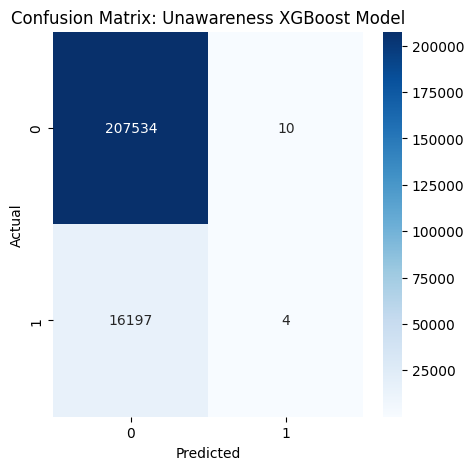

<Figure size 800x600 with 0 Axes>

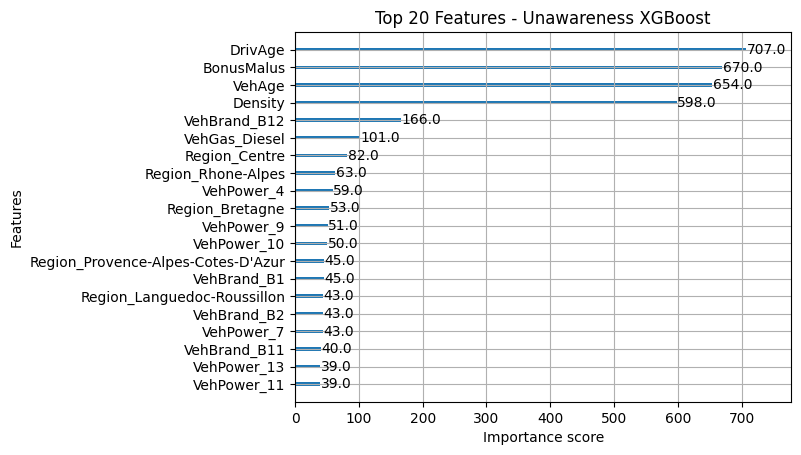


Group summary - unawareness XGBoost model
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.085312  106114
1      1           0.080064                    0.084151  117631

Unawareness XGBoost summary table
      model       scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Boosting  Unawareness  0.927565  0.609073  0.254407     0.066242         0.084701

Best-estimate vs unawareness XGBoost comparison
      model         scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Boosting  Best-estimate  0.927560  0.616634  0.253752     0.066138         0.084710
1  Boosting    Unawareness  0.927565  0.609073  0.254407     0.066242         0.084701


In [ ]:
# =========================
# 61. Unawareness XGBoost model
# =========================

unawareness_xgb = xgb.XGBClassifier(
    random_state=SEED,
    eval_metric="logloss",
    tree_method="hist",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8
)

unawareness_xgb.fit(
    X_train_unawareness_enc,
    y_train_fair,
    sample_weight=w_train_fair
)

# Predicted probabilities and binary predictions
pred_unawareness_xgb_prob = unawareness_xgb.predict_proba(X_test_unawareness_enc)[:, 1]

unawareness_xgb_metrics, pred_unawareness_xgb_class = summarize_binary_predictions(
    y_test_fair,
    pred_unawareness_xgb_prob,
    threshold=THRESHOLD
)

print("\nUnawareness Boosting results")
for k, v in unawareness_xgb_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_unawareness_xgb_class,
    "Confusion Matrix: Unawareness XGBoost Model"
)

# =========================
# 62. Feature importance
# =========================

plt.figure(figsize=(8, 6))
plot_importance(unawareness_xgb, max_num_features=20)
plt.title("Top 20 Features - Unawareness XGBoost")
plt.show()

# =========================
# 63. Group-level predicted means by SexVP
# =========================

unawareness_xgb_group_summary = pd.DataFrame({
    "SexVP": X_test_fair_all[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_unawareness_xgb_prob": pred_unawareness_xgb_prob
})

group_summary_unawareness_xgb = (
    unawareness_xgb_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_unawareness_xgb_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - unawareness XGBoost model")
print(group_summary_unawareness_xgb)

# =========================
# 64. Save results table
# =========================

unawareness_xgb_results = pd.DataFrame({
    "model": ["Boosting"],
    "scheme": ["Unawareness"],
    "accuracy": [unawareness_xgb_metrics["accuracy"]],
    "auc": [unawareness_xgb_metrics["auc"]],
    "log_loss": [unawareness_xgb_metrics["log_loss"]],
    "brier_score": [unawareness_xgb_metrics["brier_score"]],
    "mean_prediction": [unawareness_xgb_metrics["mean_prediction"]]
})

print("\nUnawareness XGBoost summary table")
print(unawareness_xgb_results)

# =========================
# 65. Compare best-estimate vs unawareness within XGBoost
# =========================

xgb_scheme_comparison = pd.concat(
    [best_estimate_xgb_results, unawareness_xgb_results],
    ignore_index=True
)

print("\nBest-estimate vs unawareness XGBoost comparison")
print(xgb_scheme_comparison)


Aware Boosting results
accuracy: 0.9276
auc: 0.6087
log_loss: 0.2543
brier_score: 0.0662
mean_prediction: 0.0848


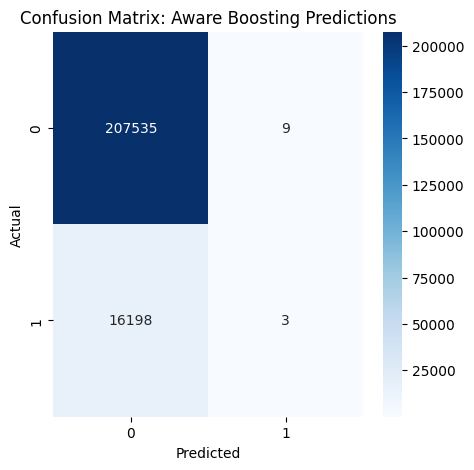


Group summary - Aware XGBoost
   SexVP  actual_claim_rate  mean_predicted_probability       n
0      0           0.063922                    0.085759  106114
1      1           0.080064                    0.083916  117631

Aware XGBoost summary table
      model scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Boosting  Aware  0.927565  0.608667  0.254276     0.066194          0.08479

Best-estimate vs Unawareness vs Aware Boosting
      model         scheme  accuracy       auc  log_loss  brier_score  mean_prediction
0  Boosting  Best-estimate  0.927560  0.616634  0.253752     0.066138         0.084710
1  Boosting    Unawareness  0.927565  0.609073  0.254407     0.066242         0.084701
2  Boosting          Aware  0.927565  0.608667  0.254276     0.066194         0.084790

Scheme-gap table - Boosting
      model                   comparison  mean_signed_gap  mean_absolute_gap  mean_gap_group0  mean_gap_group1
0  Boosting  Best-estimate - Unawareness         0.000

In [ ]:
# =========================
# 66. Aware XGBoost predictions
# =========================

# Counterfactual copies of the best-estimate test set
X_test_xgb_cf_0 = X_test_best_estimate.copy()
X_test_xgb_cf_1 = X_test_best_estimate.copy()

# Set protected variable to each possible value
X_test_xgb_cf_0[D_col] = 0
X_test_xgb_cf_1[D_col] = 1

# Encode with the already fitted best-estimate encoder
X_test_xgb_cf_0_enc = transform_with_fitted_encoder(
    X_test_xgb_cf_0,
    encoder_best_estimate,
    be_cat_cols,
    be_num_cols
)

X_test_xgb_cf_1_enc = transform_with_fitted_encoder(
    X_test_xgb_cf_1,
    encoder_best_estimate,
    be_cat_cols,
    be_num_cols
)

# Predict under both counterfactual protected-group assignments
pred_xgb_cf_0_prob = best_estimate_xgb.predict_proba(X_test_xgb_cf_0_enc)[:, 1]
pred_xgb_cf_1_prob = best_estimate_xgb.predict_proba(X_test_xgb_cf_1_enc)[:, 1]

# Average over empirical protected-group distribution from training data
pred_aware_xgb_prob = (
    prop_D0_train * pred_xgb_cf_0_prob
    + prop_D1_train * pred_xgb_cf_1_prob
)

aware_xgb_metrics, pred_aware_xgb_class = summarize_binary_predictions(
    y_test_fair,
    pred_aware_xgb_prob,
    threshold=THRESHOLD
)

print("\nAware Boosting results")
for k, v in aware_xgb_metrics.items():
    print(f"{k}: {v:.4f}")

plot_binary_confusion_matrix(
    y_test_fair,
    pred_aware_xgb_class,
    "Confusion Matrix: Aware Boosting Predictions"
)

# =========================
# 67. Group-level predicted means by SexVP
# =========================

aware_xgb_group_summary = pd.DataFrame({
    "SexVP": X_test_fair_all[D_col],
    "ClaimsVP_actual": y_test_fair,
    "pred_aware_xgb_prob": pred_aware_xgb_prob
})

group_summary_aware_xgb = (
    aware_xgb_group_summary
    .groupby("SexVP")
    .agg(
        actual_claim_rate=("ClaimsVP_actual", "mean"),
        mean_predicted_probability=("pred_aware_xgb_prob", "mean"),
        n=("ClaimsVP_actual", "size")
    )
    .reset_index()
)

print("\nGroup summary - Aware XGBoost")
print(group_summary_aware_xgb)

# =========================
# 68. Save results table
# =========================

aware_xgb_results = pd.DataFrame({
    "model": ["Boosting"],
    "scheme": ["Aware"],
    "accuracy": [aware_xgb_metrics["accuracy"]],
    "auc": [aware_xgb_metrics["auc"]],
    "log_loss": [aware_xgb_metrics["log_loss"]],
    "brier_score": [aware_xgb_metrics["brier_score"]],
    "mean_prediction": [aware_xgb_metrics["mean_prediction"]]
})

print("\nAware XGBoost summary table")
print(aware_xgb_results)

# =========================
# 69. Compare all three XGBoost schemes
# =========================

xgb_three_scheme_comparison = pd.concat(
    [best_estimate_xgb_results, unawareness_xgb_results, aware_xgb_results],
    ignore_index=True
)

print("\nBest-estimate vs Unawareness vs Aware Boosting")
print(xgb_three_scheme_comparison)

boosting_gap_table = compute_scheme_gap_table(
    pred_dict={
        "Best-estimate": pred_best_estimate_xgb_prob,
        "Unawareness": pred_unawareness_xgb_prob,
        "Aware": pred_aware_xgb_prob
    },
    sensitive_series=X_test_fair_all[D_col],
    model_name="Boosting"
)

print("\nScheme-gap table - Boosting")
print(boosting_gap_table)

In [ ]:
scheme_gap_summary_all_models = pd.concat(
    [
        restricted_gap_table,
        extended_gap_table,
        boosting_gap_table
    ],
    ignore_index=True
)

scheme_gap_summary_all_models_rounded = scheme_gap_summary_all_models.copy()
numeric_cols = scheme_gap_summary_all_models_rounded.select_dtypes(include=[np.number]).columns
scheme_gap_summary_all_models_rounded[numeric_cols] = scheme_gap_summary_all_models_rounded[numeric_cols].round(4)

print("\nCore metric: Final scheme-gap summary table across all models")
print(scheme_gap_summary_all_models_rounded)

scheme_gap_summary_all_models_rounded.to_csv("scheme_gap_summary_all_models.csv", index=False)
print("\nSaved file: scheme_gap_summary_all_models.csv")


Core metric: Final scheme-gap summary table across all models
            model                   comparison  mean_signed_gap  mean_absolute_gap  mean_gap_group0  mean_gap_group1
0  Restricted GLM  Best-estimate - Unawareness           0.0000             0.0094          -0.0099           0.0090
1  Restricted GLM        Best-estimate - Aware          -0.0001             0.0099          -0.0105           0.0093
2  Restricted GLM          Unawareness - Aware          -0.0001             0.0016          -0.0006           0.0003
3    Extended GLM  Best-estimate - Unawareness           0.0000             0.0093          -0.0098           0.0088
4    Extended GLM        Best-estimate - Aware          -0.0001             0.0097          -0.0104           0.0091
5    Extended GLM          Unawareness - Aware          -0.0001             0.0016          -0.0006           0.0003
6        Boosting  Best-estimate - Unawareness           0.0000             0.0092          -0.0091           0.0082
7

In [ ]:
# =========================
# 70. Fairness metrics for XGBoost schemes
# =========================

sensitive_test = X_test_fair_all[D_col].copy()

fairness_best_estimate_xgb = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_best_estimate_xgb_prob,
    pred_class=pred_best_estimate_xgb_class,
    sensitive_series=sensitive_test,
    scheme_name="Best-estimate"
)

fairness_unawareness_xgb = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_unawareness_xgb_prob,
    pred_class=pred_unawareness_xgb_class,
    sensitive_series=sensitive_test,
    scheme_name="Unawareness"
)

fairness_aware_xgb = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_aware_xgb_prob,
    pred_class=pred_aware_xgb_class,
    sensitive_series=sensitive_test,
    scheme_name="Aware"
)

fairness_metrics_comparison_xgb = pd.concat(
    [
        fairness_best_estimate_xgb,
        fairness_unawareness_xgb,
        fairness_aware_xgb
    ],
    ignore_index=True
)

print("\nCore fairness metrics comparison - Boosting")
print(fairness_metrics_comparison_xgb)

# =========================
# 71. Group-level comparison table for XGBoost
# =========================

group_prediction_comparison_xgb = pd.DataFrame({
    "scheme": ["Best-estimate", "Unawareness", "Aware"],
    "mean_pred_group0": [
        group_summary_best_estimate_xgb.loc[
            group_summary_best_estimate_xgb["SexVP"] == 0,
            "mean_predicted_probability"
        ].values[0],
        group_summary_unawareness_xgb.loc[
            group_summary_unawareness_xgb["SexVP"] == 0,
            "mean_predicted_probability"
        ].values[0],
        group_summary_aware_xgb.loc[
            group_summary_aware_xgb["SexVP"] == 0,
            "mean_predicted_probability"
        ].values[0]
    ],
    "mean_pred_group1": [
        group_summary_best_estimate_xgb.loc[
            group_summary_best_estimate_xgb["SexVP"] == 1,
            "mean_predicted_probability"
        ].values[0],
        group_summary_unawareness_xgb.loc[
            group_summary_unawareness_xgb["SexVP"] == 1,
            "mean_predicted_probability"
        ].values[0],
        group_summary_aware_xgb.loc[
            group_summary_aware_xgb["SexVP"] == 1,
            "mean_predicted_probability"
        ].values[0]
    ]
})

group_prediction_comparison_xgb["difference_group1_minus_group0"] = (
    group_prediction_comparison_xgb["mean_pred_group1"]
    - group_prediction_comparison_xgb["mean_pred_group0"]
)

group_prediction_comparison_xgb["ratio_group1_over_group0"] = (
    group_prediction_comparison_xgb["mean_pred_group1"]
    / group_prediction_comparison_xgb["mean_pred_group0"]
)

print("\nGroup prediction comparison - XGBoost")
print(group_prediction_comparison_xgb)

# =========================
# 72. Final XGBoost fairness summary table
# =========================

fairness_summary_table_xgb = (
    xgb_three_scheme_comparison
    .merge(
        fairness_metrics_comparison_xgb,
        on="scheme",
        how="left"
    )
)

fairness_summary_table_xgb = fairness_summary_table_xgb[
    [
        "scheme",
        "accuracy",
        "auc",
        "log_loss",
        "brier_score",
        "mean_prediction",
        "dp_ratio_binary",
        "dp_difference_binary",
        "dp_ratio_probability",
        "dp_difference_probability",
        "wasserstein_probability",
        "equalized_odds_ratio_binary",
        "mean_pred_prob_group0",
        "mean_pred_prob_group1"
    ]
]

fairness_summary_table_xgb_rounded = fairness_summary_table_xgb.copy()
numeric_cols = fairness_summary_table_xgb_rounded.select_dtypes(include=[np.number]).columns
fairness_summary_table_xgb_rounded[numeric_cols] = fairness_summary_table_xgb_rounded[numeric_cols].round(4)

print("\nFinal fairness summary table - XGBoost")
print(fairness_summary_table_xgb_rounded)

# =========================
# 73. Optional export
# =========================

fairness_summary_table_xgb_rounded.to_csv("fairness_summary_table_xgb.csv", index=False)
print("\nSaved file: fairness_summary_table_xgb.csv")


Core fairness metrics comparison - Boosting
          scheme  dp_ratio_binary  dp_difference_binary  dp_ratio_probability  dp_difference_probability  \
0  Best-estimate         0.492682              0.000039              1.211225                   0.016104   
1    Unawareness         0.443414              0.000047              0.986394                  -0.001161   
2          Aware         0.221707              0.000066              0.978514                  -0.001843   

   wasserstein_probability  equalized_odds_ratio_binary  mean_pred_prob_group0  mean_pred_prob_group1  
0                 0.016104                     0.466894               0.076243               0.092347  
1                 0.001226                     0.272355               0.085312               0.084151  
2                 0.001902                     0.136177               0.085759               0.083916  

Group prediction comparison - XGBoost
          scheme  mean_pred_group0  mean_pred_group1  difference_gr

In [ ]:
# =========================
# 32A. Fairness metrics for Restricted GLM schemes
# =========================

fairness_restricted_best_estimate = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_restricted_best_estimate_prob,
    pred_class=pred_restricted_best_estimate_class,
    sensitive_series=df_fair_test[D_col],
    scheme_name="Best-estimate"
)

fairness_restricted_unawareness = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_restricted_unawareness_prob,
    pred_class=pred_restricted_unawareness_class,
    sensitive_series=df_fair_test[D_col],
    scheme_name="Unawareness"
)

fairness_restricted_aware = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_restricted_aware_prob,
    pred_class=pred_restricted_aware_class,
    sensitive_series=df_fair_test[D_col],
    scheme_name="Aware"
)

fairness_metrics_restricted_glm = pd.concat(
    [
        fairness_restricted_best_estimate,
        fairness_restricted_unawareness,
        fairness_restricted_aware
    ],
    ignore_index=True
)

print("\nCore fairness metrics - Restricted GLM")
print(fairness_metrics_restricted_glm)

# =========================
# 32B. Fairness metrics for Extended GLM schemes
# =========================

fairness_extended_best_estimate = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_extended_best_estimate_prob,
    pred_class=pred_extended_best_estimate_class,
    sensitive_series=df_fair_test[D_col],
    scheme_name="Best-estimate"
)

fairness_extended_unawareness = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_extended_unawareness_prob,
    pred_class=pred_extended_unawareness_class,
    sensitive_series=df_fair_test[D_col],
    scheme_name="Unawareness"
)

fairness_extended_aware = compute_fairness_metrics(
    y_true=y_test_fair,
    pred_prob=pred_extended_aware_prob,
    pred_class=pred_extended_aware_class,
    sensitive_series=df_fair_test[D_col],
    scheme_name="Aware"
)

fairness_metrics_extended_glm = pd.concat(
    [
        fairness_extended_best_estimate,
        fairness_extended_unawareness,
        fairness_extended_aware
    ],
    ignore_index=True
)

print("\nCore fairness metrics - Extended GLM")
print(fairness_metrics_extended_glm)

# =========================
# 32C. Relabel XGBoost branch as Boosting
# =========================

boosting_three_scheme_comparison = xgb_three_scheme_comparison.copy()
boosting_three_scheme_comparison["model"] = "Boosting"

fairness_metrics_boosting = fairness_metrics_comparison_xgb.copy()

print("\nBoosting three-scheme comparison")
print(boosting_three_scheme_comparison)

print("\nCore fairness metrics - Boosting")
print(fairness_metrics_boosting)

# =========================
# 32D. Final fairness summary tables for each model class
# =========================

fairness_summary_restricted_glm = restricted_glm_three_scheme_comparison.merge(
    fairness_metrics_restricted_glm,
    on="scheme",
    how="left"
)

fairness_summary_extended_glm = extended_glm_three_scheme_comparison.merge(
    fairness_metrics_extended_glm,
    on="scheme",
    how="left"
)

fairness_summary_boosting = boosting_three_scheme_comparison.merge(
    fairness_metrics_boosting,
    on="scheme",
    how="left"
)

# Standardize model labels
fairness_summary_restricted_glm["model"] = "Restricted GLM"
fairness_summary_extended_glm["model"] = "Extended GLM"
fairness_summary_boosting["model"] = "Boosting"

# Combine into one final table
fairness_summary_all_models = pd.concat(
    [
        fairness_summary_restricted_glm,
        fairness_summary_extended_glm,
        fairness_summary_boosting
    ],
    ignore_index=True
)

fairness_summary_all_models = fairness_summary_all_models[
    [
        "model",
        "scheme",
        "accuracy",
        "auc",
        "log_loss",
        "brier_score",
        "mean_prediction",
        "dp_ratio_binary",
        "dp_difference_binary",
        "dp_ratio_probability",
        "dp_difference_probability",
        "wasserstein_probability",
        "equalized_odds_ratio_binary",
        "mean_pred_prob_group0",
        "mean_pred_prob_group1"
    ]
]

fairness_summary_all_models_rounded = fairness_summary_all_models.copy()
numeric_cols = fairness_summary_all_models_rounded.select_dtypes(include=[np.number]).columns
fairness_summary_all_models_rounded[numeric_cols] = fairness_summary_all_models_rounded[numeric_cols].round(4)

print("\nFinal fairness summary table across all three model classes")
print(fairness_summary_all_models_rounded)

# =========================
# 32E. Optional export
# =========================

fairness_summary_all_models_rounded.to_csv("fairness_summary_all_models.csv", index=False)
print("\nSaved file: fairness_summary_all_models.csv")


Core fairness metrics - Restricted GLM
          scheme  dp_ratio_binary  dp_difference_binary  dp_ratio_probability  dp_difference_probability  \
0  Best-estimate         0.221707              0.000033              1.229872                   0.017501   
1    Unawareness         0.554267              0.000008              0.983856                  -0.001389   
2          Aware         0.554267              0.000008              0.973482                  -0.002298   

   wasserstein_probability  equalized_odds_ratio_binary  mean_pred_prob_group0  mean_pred_prob_group1  
0                 0.017502                          0.0               0.076132               0.093633  
1                 0.001461                          0.0               0.086058               0.084669  
2                 0.002317                          0.0               0.086670               0.084372  

Core fairness metrics - Extended GLM
          scheme  dp_ratio_binary  dp_difference_binary  dp_ratio_probabi

In [ ]:
core_fairness_summary_all_models = fairness_summary_all_models[
    [
        "model",
        "scheme",
        "accuracy",
        "auc",
        "log_loss",
        "brier_score",
        "mean_prediction",
        "dp_ratio_probability",
        "dp_difference_probability",
        "wasserstein_probability",
        "mean_pred_prob_group0",
        "mean_pred_prob_group1"
    ]
]

core_fairness_summary_all_models_rounded = core_fairness_summary_all_models.copy()
numeric_cols = core_fairness_summary_all_models_rounded.select_dtypes(include=[np.number]).columns
core_fairness_summary_all_models_rounded[numeric_cols] = core_fairness_summary_all_models_rounded[numeric_cols].round(4)

print("\nCore fairness summary table across all models")
print(core_fairness_summary_all_models_rounded)

secondary_fairness_summary_all_models = fairness_summary_all_models[
    [
        "model",
        "scheme",
        "dp_ratio_binary",
        "dp_difference_binary",
        "equalized_odds_ratio_binary"
    ]
]

secondary_fairness_summary_all_models_rounded = secondary_fairness_summary_all_models.copy()
numeric_cols = secondary_fairness_summary_all_models_rounded.select_dtypes(include=[np.number]).columns
secondary_fairness_summary_all_models_rounded[numeric_cols] = secondary_fairness_summary_all_models_rounded[numeric_cols].round(4)

print("\nSecondary fairness summary table across all models")
print(secondary_fairness_summary_all_models_rounded)

core_fairness_summary_all_models_rounded.to_csv("core_fairness_summary_all_models.csv", index=False)
secondary_fairness_summary_all_models_rounded.to_csv("secondary_fairness_summary_all_models.csv", index=False)

print("\nSaved files:")
print("- core_fairness_summary_all_models.csv")
print("- secondary_fairness_summary_all_models.csv")

thesis_interpretation_table = build_thesis_interpretation_table(
    core_fairness_summary_all_models
)

thesis_interpretation_table_rounded = thesis_interpretation_table.copy()
numeric_cols = thesis_interpretation_table_rounded.select_dtypes(include=[np.number]).columns
thesis_interpretation_table_rounded[numeric_cols] = thesis_interpretation_table_rounded[numeric_cols].round(4)

print("\nThesis interpretation table")
print(thesis_interpretation_table_rounded)

thesis_interpretation_table_rounded.to_csv("thesis_interpretation_table.csv", index=False)
print("\nSaved file: thesis_interpretation_table.csv")



Core fairness summary table across all models
            model         scheme  accuracy     auc  log_loss  brier_score  mean_prediction  dp_ratio_probability  \
0  Restricted GLM  Best-estimate    0.9276  0.5746    0.2585       0.0670           0.0853                1.2299   
1  Restricted GLM    Unawareness    0.9276  0.5636    0.2591       0.0671           0.0853                0.9839   
2  Restricted GLM          Aware    0.9276  0.5631    0.2592       0.0671           0.0855                0.9735   
3    Extended GLM  Best-estimate    0.9276  0.5779    0.2581       0.0670           0.0839                1.2285   
4    Extended GLM    Unawareness    0.9276  0.5684    0.2586       0.0670           0.0839                0.9826   
5    Extended GLM          Aware    0.9276  0.5680    0.2587       0.0670           0.0840                0.9722   
6        Boosting  Best-estimate    0.9276  0.6166    0.2538       0.0661           0.0847                1.2112   
7        Boosting    Unaw

In [ ]:
# =========================
# PART D. Interpretation and mapping outputs
# Metric-to-dimension mapping and thesis discussion tables
# =========================

# =========================
# 51. Metric-to-dimension mapping table
# =========================

metric_mapping_table = pd.DataFrame([
    {
        "metric": "Demographic parity (binary)",
        "what_it_measures": "Whether the rate of positive predictions is similar across protected groups after applying a threshold.",
        "controllability": "Not directly captured",
        "causal_relevance": "Not directly captured",
        "privacy": "Not captured",
        "transparency": "Only indirectly, through simple interpretability of the metric itself",
        "solidarity": "Partially captured, because group-level parity in outcomes can reflect distributional equalization",
        "main_limitation": "Highly sensitive to threshold choice and class imbalance; ignores whether variables are behavior-related, justified, or intrusive."
    },
    {
        "metric": "Demographic parity (probability-based)",
        "what_it_measures": "Whether the average predicted probabilities are similar across protected groups.",
        "controllability": "Not directly captured",
        "causal_relevance": "Not directly captured",
        "privacy": "Not captured",
        "transparency": "Only indirectly, through ease of comparing group averages",
        "solidarity": "Partially captured, because similar mean predictions reduce group-level disparity",
        "main_limitation": "Does not indicate whether prediction differences are justified, understandable, controllable, or acceptable to consumers."
    },
    {
        "metric": "Equalized odds (binary)",
        "what_it_measures": "Whether error behavior conditional on the realized outcome is similar across protected groups.",
        "controllability": "Not captured",
        "causal_relevance": "Not directly captured",
        "privacy": "Not captured",
        "transparency": "Only indirectly, because the metric can be defined clearly but may be hard to explain to consumers",
        "solidarity": "Only weakly captured, since the metric focuses on error parity rather than redistribution or affordability",
        "main_limitation": "Threshold-sensitive and difficult to interpret behaviorally; equal error rates do not imply perceived fairness."
    },
    {
        "metric": "Group mean predicted probabilities",
        "what_it_measures": "Direct comparison of average predicted risk signals across protected groups.",
        "controllability": "Not directly captured",
        "causal_relevance": "Not directly captured",
        "privacy": "Not captured",
        "transparency": "Moderately captured, because the comparison is intuitive and easy to communicate",
        "solidarity": "Partially captured, because smaller group gaps can be interpreted as greater distributional parity",
        "main_limitation": "Descriptive only; does not explain why groups differ or whether any remaining difference is justified."
    },
    {
        "metric": "Proxy-detectability AUC",
        "what_it_measures": "How strongly the protected attribute can be inferred from non-sensitive variables.",
        "controllability": "Not captured",
        "causal_relevance": "Indirectly related, because strong proxy detectability may signal that allowed variables encode protected-group information",
        "privacy": "Not directly captured, but suggests hidden sensitive information remains present in features",
        "transparency": "Weakly captured, since it can reveal hidden structure but not make the pricing logic itself understandable",
        "solidarity": "Not directly captured",
        "main_limitation": "Shows proxy information exists, but does not by itself establish unfair pricing or customer-perceived unfairness."
    }
])

print("\nMetric-to-dimension mapping table")
print(metric_mapping_table)

# =========================
# 52. Rounded version for thesis use
# =========================

metric_mapping_table_thesis = metric_mapping_table.copy()
print("\nRounded metric mapping table for thesis")
print(metric_mapping_table_thesis)

# =========================
# 53. Optional export
# =========================

metric_mapping_table_thesis.to_csv("metric_mapping_table_thesis.csv", index=False)
print("\nSaved file: metric_mapping_table_thesis.csv")


Metric-to-dimension mapping table
                                   metric                                   what_it_measures        controllability  \
0             Demographic parity (binary)  Whether the rate of positive predictions is si...  Not directly captured   
1  Demographic parity (probability-based)  Whether the average predicted probabilities ar...  Not directly captured   
2                 Equalized odds (binary)  Whether error behavior conditional on the real...           Not captured   
3      Group mean predicted probabilities  Direct comparison of average predicted risk si...  Not directly captured   
4                 Proxy-detectability AUC  How strongly the protected attribute can be in...           Not captured   

                                    causal_relevance                                            privacy  \
0                              Not directly captured                                       Not captured   
1                              Not d

In [ ]:
# =========================
# 54. Interpretation table: empirical findings vs fairness dimensions
# =========================

scheme_interpretation_table = pd.DataFrame([
    {
        "scheme": "Best-estimate",
        "empirical_result": "Best predictive performance, but largest probability-based group disparity.",
        "what_metrics_suggest": "Direct inclusion of the protected variable increases predictive fit but also leads to the strongest measured disparity across groups.",
        "what_this_supports": "Model-based metrics indicate weaker parity performance and therefore less favorable group-based fairness results.",
        "what_remains_unresolved": "The metrics do not tell us whether the variables are controllable, causally meaningful, privacy-intrusive, or understandable to policyholders."
    },
    {
        "scheme": "Unawareness",
        "empirical_result": "Slightly weaker predictive performance, but much smaller group disparity.",
        "what_metrics_suggest": "Removing the protected variable compresses group-level prediction differences substantially, with only modest loss of predictive performance.",
        "what_this_supports": "Unawareness improves measured parity, but does not by itself prove that proxy effects are eliminated or that the resulting pricing is customer-perceived as fair.",
        "what_remains_unresolved": "The metrics do not reveal whether remaining predictors still encode protected-group information, nor whether the resulting pricing is viewed as legitimate or transparent."
    },
    {
        "scheme": "Aware",
        "empirical_result": "Predictive performance slightly below best-estimate and close to unawareness, with the smallest probability-based group disparity in this setup.",
        "what_metrics_suggest": "Averaging over the protected-variable distribution reduces direct dependence on realized group membership and improves parity measures.",
        "what_this_supports": "Aware prediction appears most favorable under the probability-based disparity metrics used here.",
        "what_remains_unresolved": "Even if parity improves, the metrics do not show whether the underlying variables are behaviorally controllable, causally justified, privacy-respecting, or socially acceptable."
    }
])

print("\nScheme interpretation table")
print(scheme_interpretation_table)

# =========================
# 55. Dimension-level conclusion table
# =========================

dimension_conclusion_table = pd.DataFrame([
    {
        "dimension": "Controllability",
        "what_the_results_tell_us": "Nothing direct. The computed metrics compare group disparities in predictions, not whether the pricing variables are under the policyholder’s control.",
        "thesis_implication": "Model-based fairness results cannot by themselves establish customer-perceived fairness with respect to controllability."
    },
    {
        "dimension": "Causal relevance",
        "what_the_results_tell_us": "Only indirectly. Proxy-detectability suggests that protected-group information remains encoded in allowed variables, but the metrics do not determine whether variables are causally justified risk factors.",
        "thesis_implication": "Statistical parity results cannot be interpreted as evidence that the pricing variables are logically or causally fair."
    },
    {
        "dimension": "Privacy",
        "what_the_results_tell_us": "Nothing direct. The metrics do not assess whether the data used are intrusive or socially acceptable to collect.",
        "thesis_implication": "A scheme may improve measured parity while still relying on data that customers perceive as too personal or inappropriate."
    },
    {
        "dimension": "Transparency",
        "what_the_results_tell_us": "Only indirectly. The metrics themselves are interpretable, but they do not indicate whether the pricing model is understandable from the customer’s perspective.",
        "thesis_implication": "Measured fairness and explainability are related but distinct; improved metric values do not guarantee perceived transparency."
    },
    {
        "dimension": "Solidarity",
        "what_the_results_tell_us": "Partially. Smaller group-level prediction gaps and parity-oriented metrics provide some evidence of reduced distributional disparity across protected groups.",
        "thesis_implication": "Among the customer-perceived dimensions, solidarity is the one most clearly reflected by the fairness metrics used here, but only partially."
    }
])

print("\nDimension-level conclusion table")
print(dimension_conclusion_table)

# =========================
# 56. Optional export
# =========================

scheme_interpretation_table.to_csv("scheme_interpretation_table.csv", index=False)
dimension_conclusion_table.to_csv("dimension_conclusion_table.csv", index=False)

print("\nSaved files:")
print("- scheme_interpretation_table.csv")
print("- dimension_conclusion_table.csv")


Scheme interpretation table
          scheme                                   empirical_result  \
0  Best-estimate  Best predictive performance, but largest proba...   
1    Unawareness  Slightly weaker predictive performance, but mu...   
2          Aware  Predictive performance slightly below best-est...   

                                what_metrics_suggest                                 what_this_supports  \
0  Direct inclusion of the protected variable inc...  Model-based metrics indicate weaker parity per...   
1  Removing the protected variable compresses gro...  Unawareness improves measured parity, but does...   
2  Averaging over the protected-variable distribu...  Aware prediction appears most favorable under ...   

                             what_remains_unresolved  
0  The metrics do not tell us whether the variabl...  
1  The metrics do not reveal whether remaining pr...  
2  Even if parity improves, the metrics do not sh...  

Dimension-level conclusion table
   

In [ ]:
# =========================
# FINAL MAIN THESIS OUTPUTS
# =========================

print("\n==============================")
print("MAIN THESIS OUTPUT 1: Proxy-detectability")
print("==============================")
print(proxy_results.round(4))

print("\n==============================")
print("MAIN THESIS OUTPUT 2: Core fairness summary across all models")
print("==============================")
print(core_fairness_summary_all_models_rounded)

print("\n==============================")
print("MAIN THESIS OUTPUT 3: Scheme-gap summary across all models")
print("==============================")
print(scheme_gap_summary_all_models_rounded)

print("\n==============================")
print("SUPPLEMENTARY OUTPUT: Secondary fairness metrics")
print("==============================")
print(secondary_fairness_summary_all_models_rounded)

print("\n==============================")
print("MAIN THESIS OUTPUT 4: Interpretation table")
print("==============================")
print(thesis_interpretation_table_rounded)


MAIN THESIS OUTPUT 1: Proxy-detectability
      model                                               task  accuracy     auc  log_loss  brier_score
0  Boosting  Proxy-detectability: predict SexVP from non-se...     0.582  0.6067    0.6716       0.2395

MAIN THESIS OUTPUT 2: Core fairness summary across all models
            model         scheme  accuracy     auc  log_loss  brier_score  mean_prediction  dp_ratio_probability  \
0  Restricted GLM  Best-estimate    0.9276  0.5746    0.2585       0.0670           0.0853                1.2299   
1  Restricted GLM    Unawareness    0.9276  0.5636    0.2591       0.0671           0.0853                0.9839   
2  Restricted GLM          Aware    0.9276  0.5631    0.2592       0.0671           0.0855                0.9735   
3    Extended GLM  Best-estimate    0.9276  0.5779    0.2581       0.0670           0.0839                1.2285   
4    Extended GLM    Unawareness    0.9276  0.5684    0.2586       0.0670           0.0839                

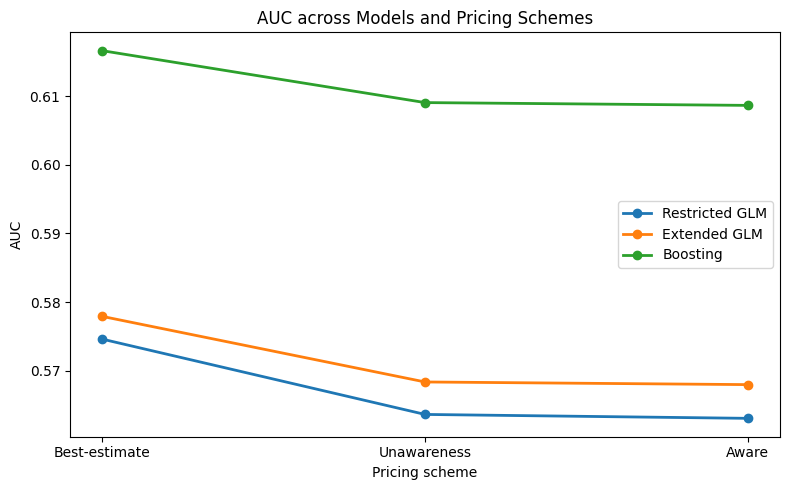

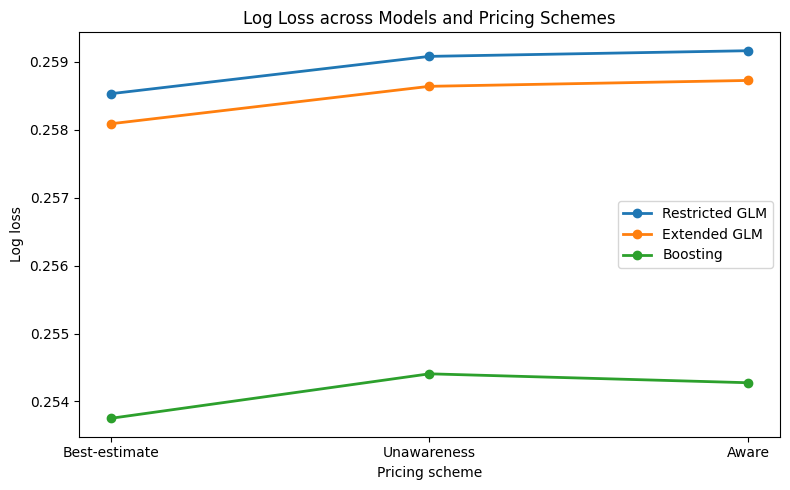

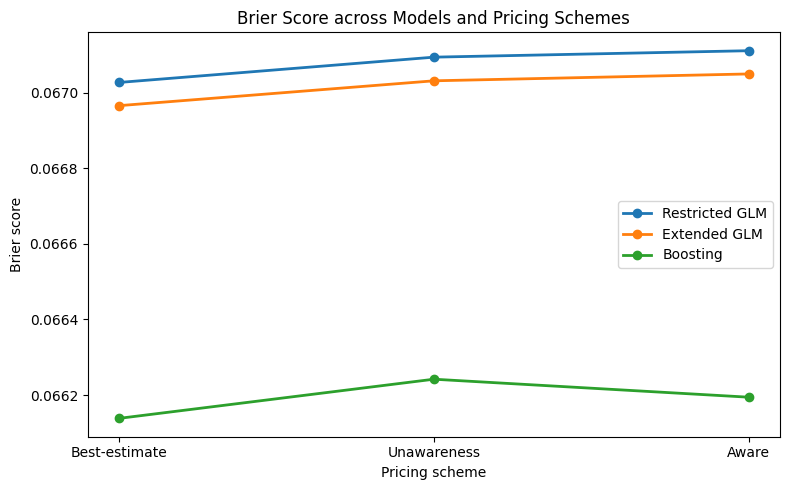

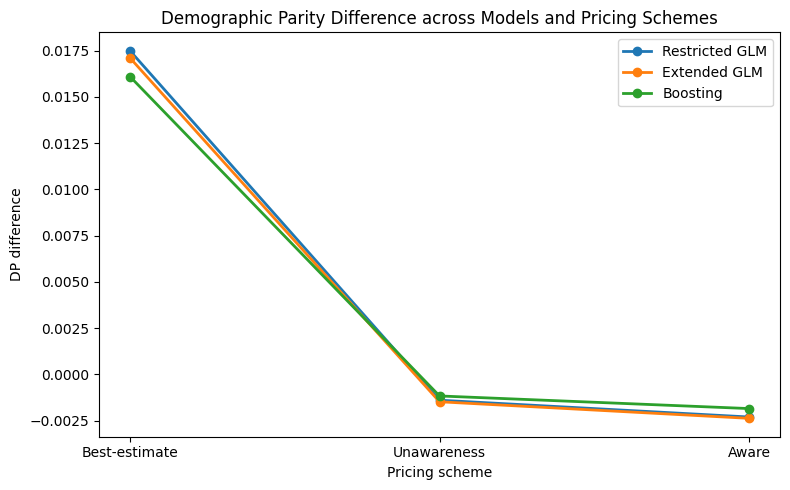

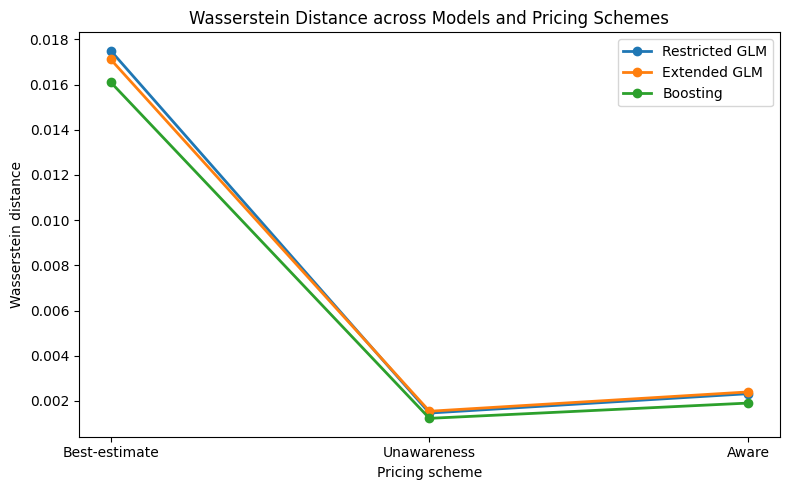

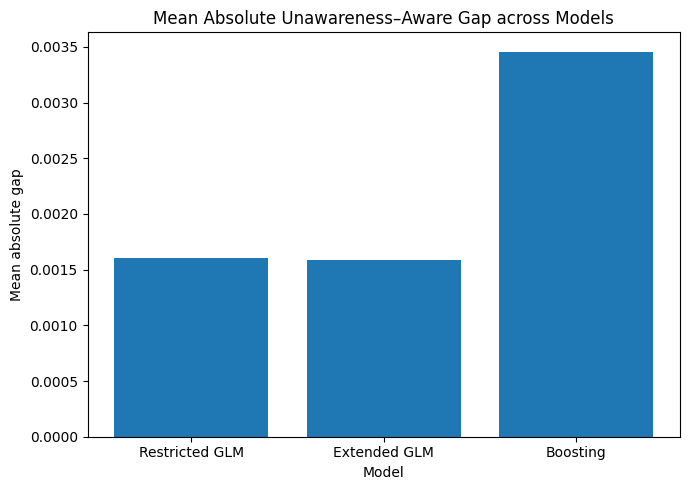

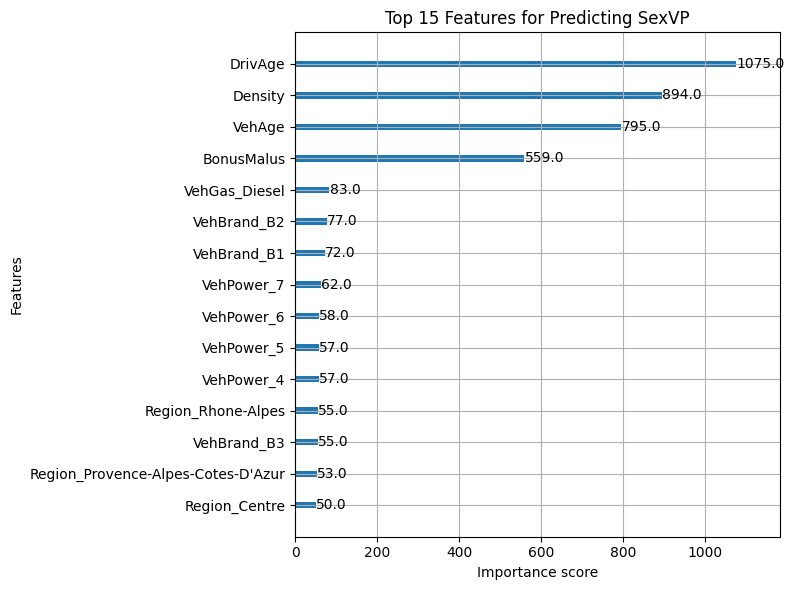


Saved thesis figures:
- main_auc_by_scheme.png
- main_brier_by_scheme.png
- main_dp_difference.png
- main_logloss_by_scheme.png
- main_wasserstein.png
- proxy_detectability_feature_importance.png
- proxy_gap_absolute.png

ZIP file created: /content/thesis_figures.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# PART E. THESIS FIGURES FOR LATEX + AUTO DOWNLOAD
# =========================

from pathlib import Path
import shutil

# For Colab download
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Create figures folder
fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Use the non-rounded tables for plotting
plot_main = core_fairness_summary_all_models.copy()
plot_gap = scheme_gap_summary_all_models.copy()

scheme_order = ["Best-estimate", "Unawareness", "Aware"]
model_order = ["Restricted GLM", "Extended GLM", "Boosting"]


def save_line_plot(df, metric, ylabel, filename, title):
    plt.figure(figsize=(8, 5))

    for model in model_order:
        sub = (
            df[df["model"] == model]
            .set_index("scheme")
            .reindex(scheme_order)
            .reset_index()
        )

        plt.plot(
            scheme_order,
            sub[metric].values,
            marker="o",
            linewidth=2,
            label=model
        )

    plt.title(title)
    plt.xlabel("Pricing scheme")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


# 1. AUC
save_line_plot(
    df=plot_main,
    metric="auc",
    ylabel="AUC",
    filename="main_auc_by_scheme.png",
    title="AUC across Models and Pricing Schemes"
)

# 2. Log loss
save_line_plot(
    df=plot_main,
    metric="log_loss",
    ylabel="Log loss",
    filename="main_logloss_by_scheme.png",
    title="Log Loss across Models and Pricing Schemes"
)

# 3. Brier score
save_line_plot(
    df=plot_main,
    metric="brier_score",
    ylabel="Brier score",
    filename="main_brier_by_scheme.png",
    title="Brier Score across Models and Pricing Schemes"
)

# 4. Demographic parity difference
save_line_plot(
    df=plot_main,
    metric="dp_difference_probability",
    ylabel="DP difference",
    filename="main_dp_difference.png",
    title="Demographic Parity Difference across Models and Pricing Schemes"
)

# 5. Wasserstein distance
save_line_plot(
    df=plot_main,
    metric="wasserstein_probability",
    ylabel="Wasserstein distance",
    filename="main_wasserstein.png",
    title="Wasserstein Distance across Models and Pricing Schemes"
)

# 6. Main proxy-effect diagnostic
proxy_gap_main = plot_gap[plot_gap["comparison"] == "Unawareness - Aware"].copy()
proxy_gap_main = proxy_gap_main.set_index("model").reindex(model_order).reset_index()

plt.figure(figsize=(7, 5))
plt.bar(proxy_gap_main["model"], proxy_gap_main["mean_absolute_gap"])
plt.title("Mean Absolute Unawareness–Aware Gap across Models")
plt.xlabel("Model")
plt.ylabel("Mean absolute gap")
plt.tight_layout()
plt.savefig(fig_dir / "proxy_gap_absolute.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 7. Proxy-detectability feature importance
fig, ax = plt.subplots(figsize=(8, 6))
plot_importance(proxy_xgb, max_num_features=15, ax=ax)
ax.set_title("Top 15 Features for Predicting SexVP")
fig.tight_layout()
fig.savefig(fig_dir / "proxy_detectability_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# Show saved files
print("\nSaved thesis figures:")
for f in sorted(fig_dir.glob("*.png")):
    print("-", f.name)

# =========================
# AUTO ZIP + DOWNLOAD
# =========================

zip_path = shutil.make_archive("thesis_figures", "zip", root_dir=fig_dir)

print(f"\nZIP file created: {zip_path}")

if IN_COLAB:
    files.download(zip_path)
else:
    print("Automatic download works in Google Colab only.")
    print("Your ZIP file is ready in the current working directory.")

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# Create figures folder
# ============================================================
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

# ============================================================
# Data for plotting
# ============================================================
plot_df = core_fairness_summary_all_models.copy()

# Short labels
model_short = {
    "Restricted GLM": "R",
    "Extended GLM": "E",
    "Boosting": "B"
}

scheme_short = {
    "Best-estimate": "BE",
    "Unawareness": "UA",
    "Aware": "AW"
}

plot_df["point_label"] = (
    plot_df["model"].map(model_short) + "-" + plot_df["scheme"].map(scheme_short)
)

# ============================================================
# Visual style
# ============================================================
scheme_colors = {
    "Best-estimate": "#D55E00",   # orange-red
    "Unawareness": "#0072B2",     # blue
    "Aware": "#009E73"            # green
}

model_markers = {
    "Restricted GLM": "o",
    "Extended GLM": "s",
    "Boosting": "^"
}

# ============================================================
# Helper function for cleaner trade-off plots
# ============================================================
def plot_tradeoff_clean(
    df,
    y_col,
    y_label,
    title,
    filename,
    add_zero_line=False,
    label_offsets=None
):
    fig, ax = plt.subplots(figsize=(10, 7))

    # Plot points
    for _, row in df.iterrows():
        x = row["auc"]
        y = row[y_col]
        model = row["model"]
        scheme = row["scheme"]
        label = row["point_label"]

        ax.scatter(
            x,
            y,
            s=130,
            color=scheme_colors[scheme],
            marker=model_markers[model],
            edgecolor="black",
            linewidth=0.8,
            alpha=0.9,
            zorder=3
        )

        # Label offsets
        dx, dy = (0.0005, 0.0001)
        if label_offsets is not None and (model, scheme) in label_offsets:
            dx, dy = label_offsets[(model, scheme)]

        ax.annotate(
            label,
            xy=(x, y),
            xytext=(x + dx, y + dy),
            textcoords="data",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.6),
            zorder=4
        )

    # Optional horizontal zero line
    if add_zero_line:
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    # Axes
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("AUC", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)

    ax.grid(True, linestyle="--", alpha=0.35)
    ax.margins(x=0.08, y=0.18)

    # Legend 1: Scheme colors
    scheme_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=scheme_colors[s],
            markeredgecolor="black",
            markersize=9,
            label=s
        )
        for s in scheme_colors
    ]

    # Legend 2: Model markers
    model_handles = [
        Line2D(
            [0], [0],
            marker=model_markers[m],
            color="black",
            linestyle="None",
            markersize=9,
            label=m
        )
        for m in model_markers
    ]

    legend1 = ax.legend(
        handles=scheme_handles,
        title="Pricing scheme",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.00)
    )
    ax.add_artist(legend1)

    ax.legend(
        handles=model_handles,
        title="Model class",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.63)
    )

    plt.tight_layout()
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()

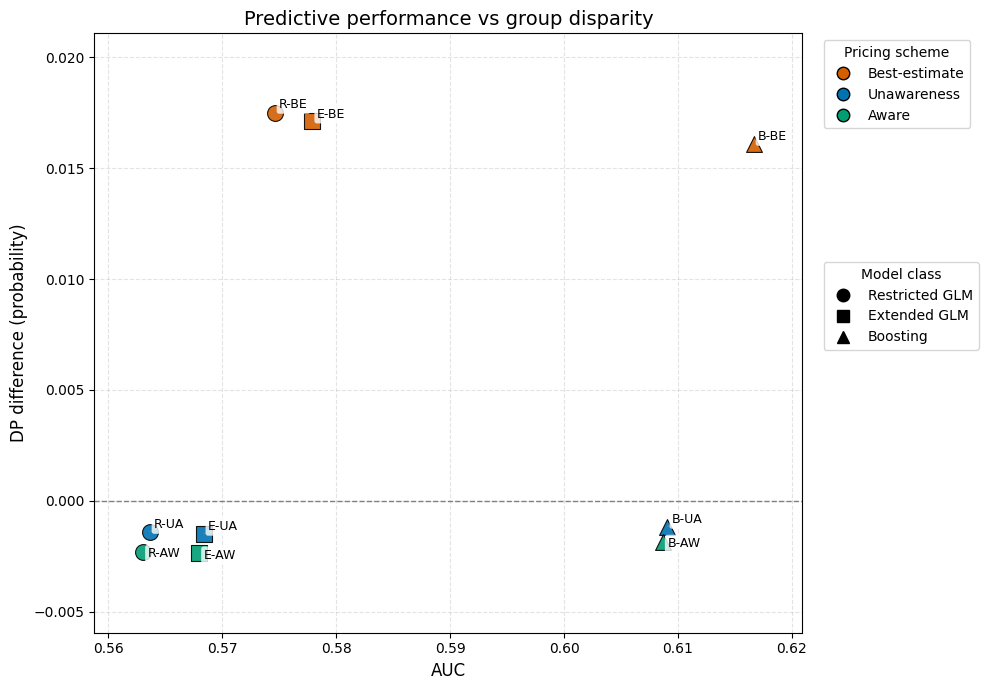

In [ ]:
dp_offsets = {
    ("Restricted GLM", "Best-estimate"): (0.0004, 0.0002),
    ("Extended GLM", "Best-estimate"):   (0.0004, 0.00015),
    ("Boosting", "Best-estimate"):       (0.0004, 0.00015),

    ("Restricted GLM", "Unawareness"):   (0.0004, 0.00015),
    ("Restricted GLM", "Aware"):         (0.0004, -0.00025),

    ("Extended GLM", "Unawareness"):     (0.0004, 0.00015),
    ("Extended GLM", "Aware"):           (0.0004, -0.00025),

    ("Boosting", "Unawareness"):         (0.0004, 0.00015),
    ("Boosting", "Aware"):               (0.0004, -0.00025),
}

plot_tradeoff_clean(
    df=plot_df,
    y_col="dp_difference_probability",
    y_label="DP difference (probability)",
    title="Predictive performance vs group disparity",
    filename="tradeoff_auc_vs_dp_clean.png",
    add_zero_line=True,
    label_offsets=dp_offsets
)

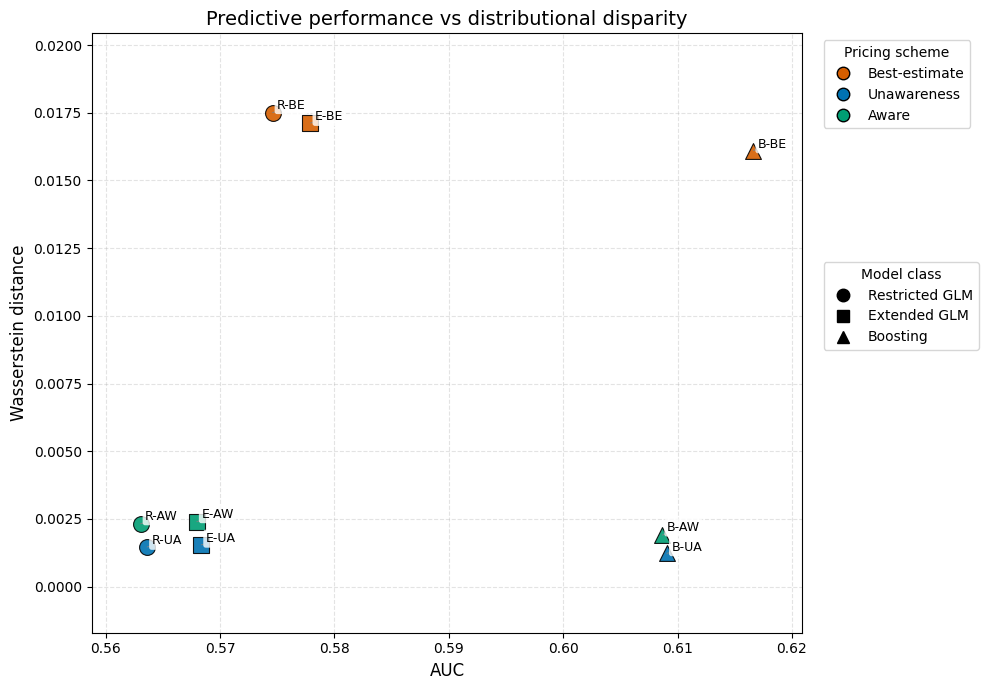

In [ ]:
wasserstein_offsets = {
    ("Restricted GLM", "Best-estimate"): (0.0004, 0.00015),
    ("Extended GLM", "Best-estimate"):   (0.0004, 0.00010),
    ("Boosting", "Best-estimate"):       (0.0004, 0.00010),

    ("Restricted GLM", "Unawareness"):   (0.0004, 0.00010),
    ("Restricted GLM", "Aware"):         (0.0004, 0.00015),

    ("Extended GLM", "Unawareness"):     (0.0004, 0.00010),
    ("Extended GLM", "Aware"):           (0.0004, 0.00015),

    ("Boosting", "Unawareness"):         (0.0004, 0.00010),
    ("Boosting", "Aware"):               (0.0004, 0.00015),
}

plot_tradeoff_clean(
    df=plot_df,
    y_col="wasserstein_probability",
    y_label="Wasserstein distance",
    title="Predictive performance vs distributional disparity",
    filename="tradeoff_auc_vs_wasserstein_clean.png",
    add_zero_line=False,
    label_offsets=wasserstein_offsets
)

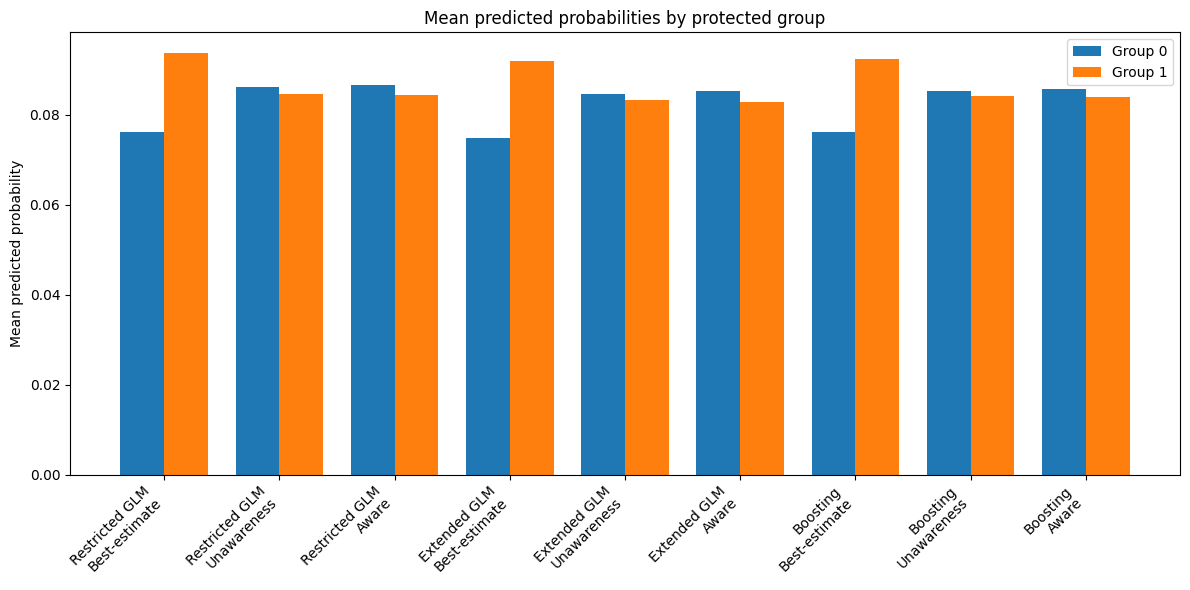

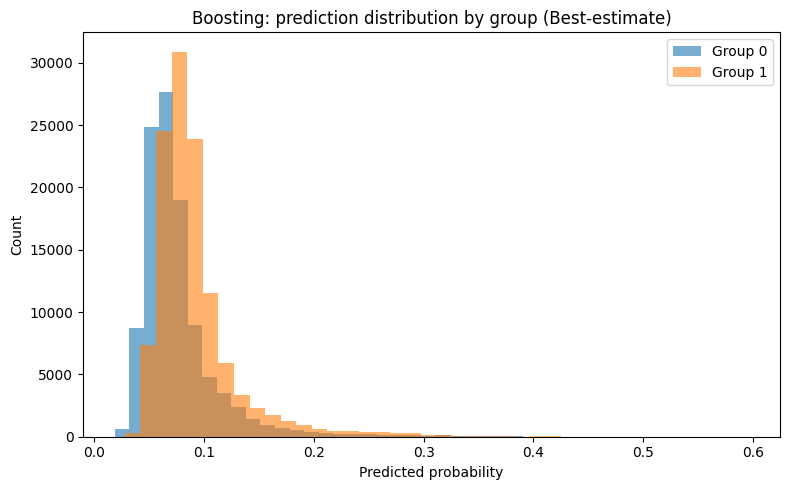

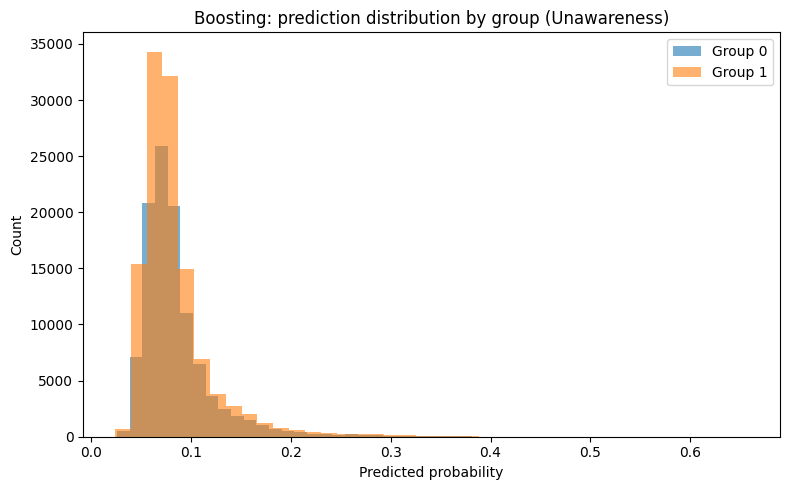

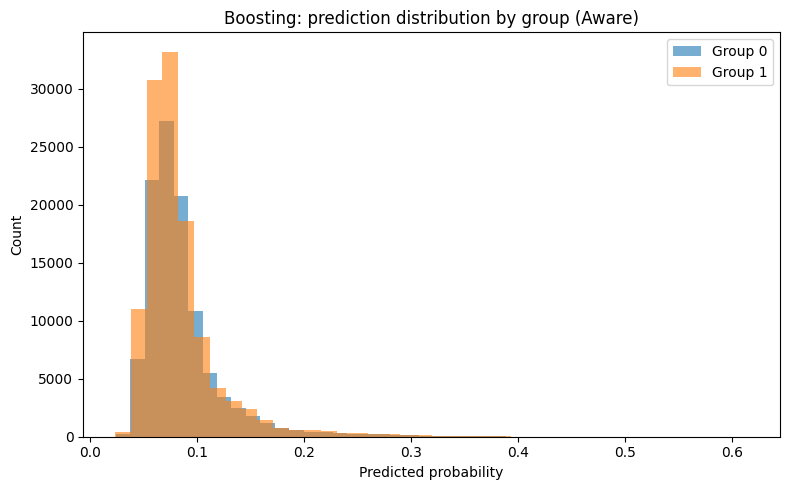

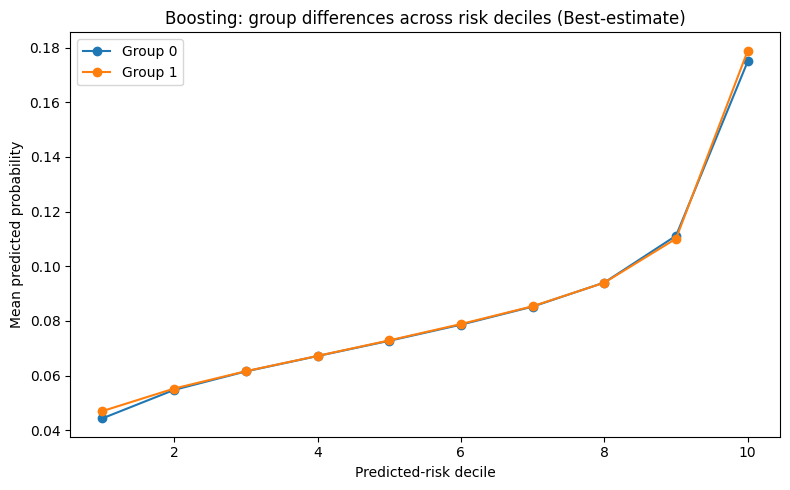

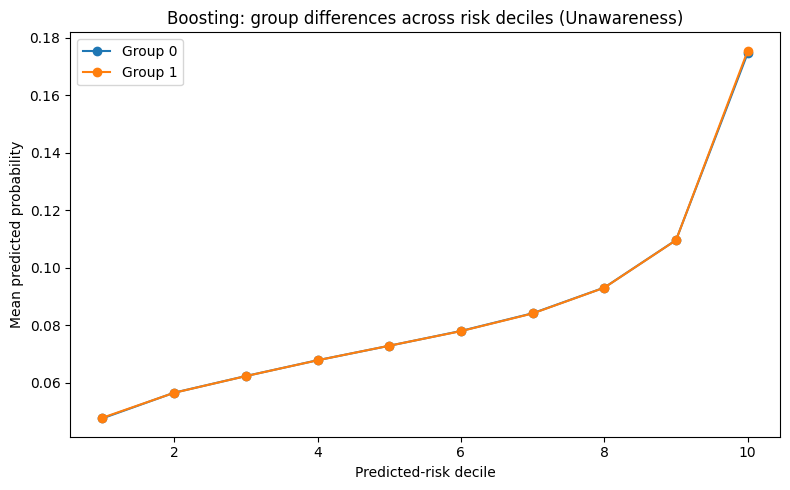

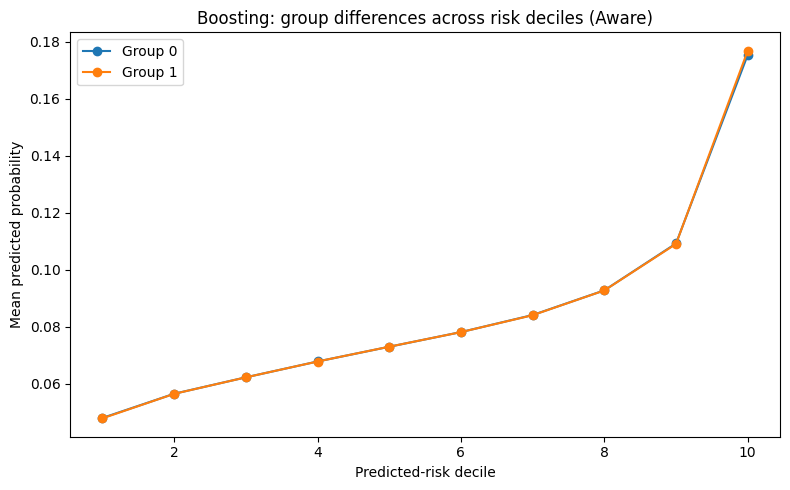

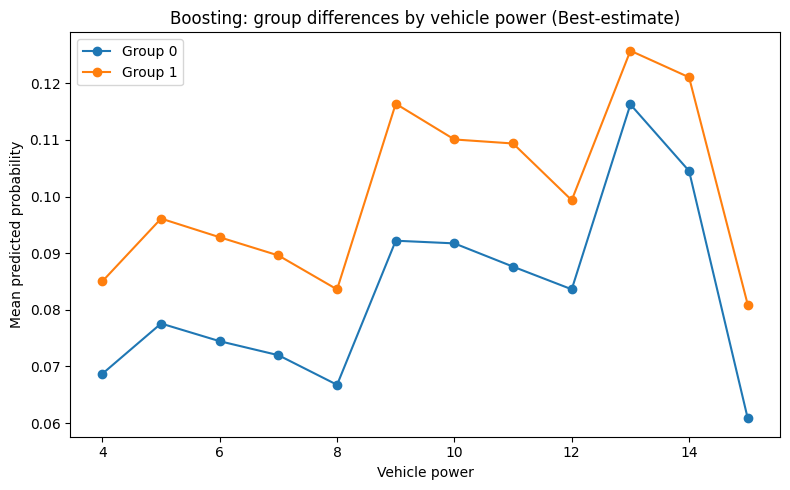

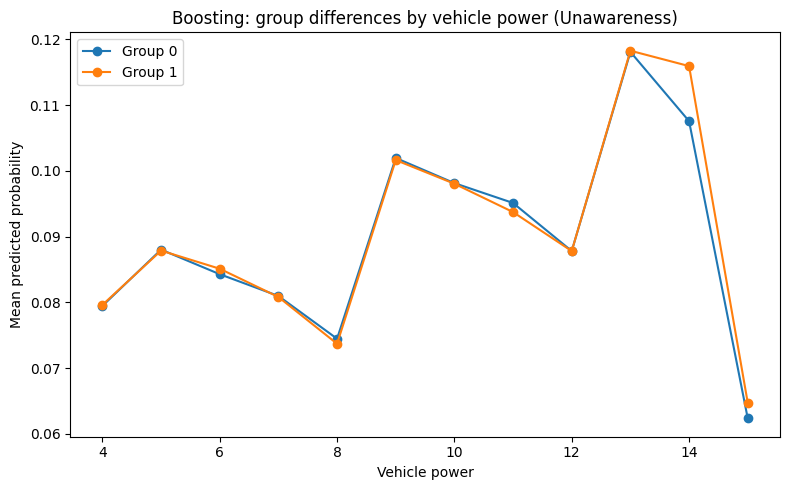

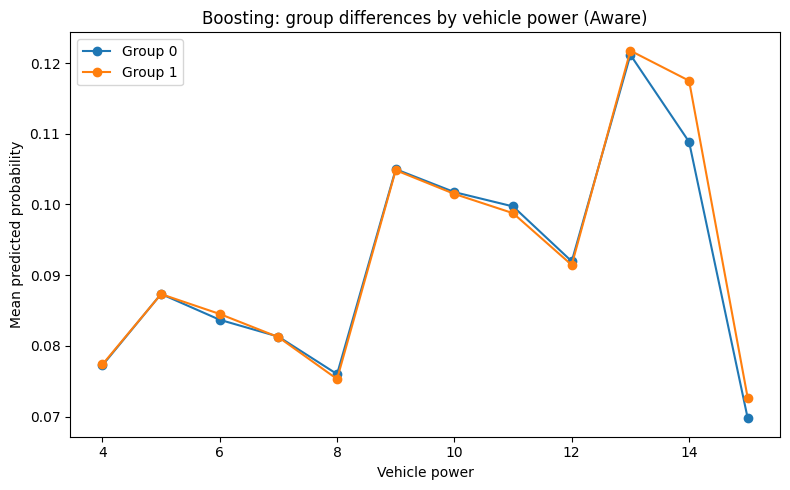

All figures saved in: /content/figures


In [ ]:
# =========================
# PART E. Thesis figures for visual intuition
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIG_DIR = Path("/content/figures")
FIG_DIR.mkdir(exist_ok=True)

def save_current_figure(filename):
    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


# -------------------------
# 3. Mean predicted probability by group and scheme
#    (all model-scheme combinations)
# -------------------------

bar_df = fairness_summary_all_models.copy()
bar_df["model_scheme"] = bar_df["model"] + "\n" + bar_df["scheme"]

x = np.arange(len(bar_df))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, bar_df["mean_pred_prob_group0"], width=width, label="Group 0")
plt.bar(x + width/2, bar_df["mean_pred_prob_group1"], width=width, label="Group 1")

plt.xticks(x, bar_df["model_scheme"], rotation=45, ha="right")
plt.ylabel("Mean predicted probability")
plt.title("Mean predicted probabilities by protected group")
plt.legend()
save_current_figure("mean_predicted_probabilities_by_group.png")

# -------------------------
# 4. Prediction distributions by protected group for Boosting
# -------------------------

boost_plot_df = pd.DataFrame({
    "SexVP": X_test_fair_all[D_col].reset_index(drop=True),
    "Best-estimate": pd.Series(pred_best_estimate_xgb_prob).reset_index(drop=True),
    "Unawareness": pd.Series(pred_unawareness_xgb_prob).reset_index(drop=True),
    "Aware": pd.Series(pred_aware_xgb_prob).reset_index(drop=True)
})

for scheme in ["Best-estimate", "Unawareness", "Aware"]:
    plt.figure(figsize=(8, 5))
    plt.hist(boost_plot_df.loc[boost_plot_df["SexVP"] == 0, scheme], bins=40, alpha=0.6, label="Group 0")
    plt.hist(boost_plot_df.loc[boost_plot_df["SexVP"] == 1, scheme], bins=40, alpha=0.6, label="Group 1")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.title(f"Boosting: prediction distribution by group ({scheme})")
    plt.legend()
    save_current_figure(f"boosting_distribution_{scheme.lower().replace('-', '_').replace(' ', '_')}.png")

# -------------------------
# 5. Gap by predicted-risk decile for Boosting
# -------------------------

decile_df = pd.DataFrame({
    "SexVP": X_test_fair_all[D_col].reset_index(drop=True),
    "Best-estimate": pd.Series(pred_best_estimate_xgb_prob).reset_index(drop=True),
    "Unawareness": pd.Series(pred_unawareness_xgb_prob).reset_index(drop=True),
    "Aware": pd.Series(pred_aware_xgb_prob).reset_index(drop=True)
})

for scheme in ["Best-estimate", "Unawareness", "Aware"]:
    tmp = decile_df[["SexVP", scheme]].copy()
    tmp["risk_decile"] = pd.qcut(tmp[scheme], q=10, labels=False, duplicates="drop") + 1

    grouped = (
        tmp.groupby(["risk_decile", "SexVP"])[scheme]
        .mean()
        .reset_index()
        .pivot(index="risk_decile", columns="SexVP", values=scheme)
    )

    plt.figure(figsize=(8, 5))
    plt.plot(grouped.index, grouped[0], marker="o", label="Group 0")
    plt.plot(grouped.index, grouped[1], marker="o", label="Group 1")
    plt.xlabel("Predicted-risk decile")
    plt.ylabel("Mean predicted probability")
    plt.title(f"Boosting: group differences across risk deciles ({scheme})")
    plt.legend()
    save_current_figure(f"boosting_deciles_{scheme.lower().replace('-', '_').replace(' ', '_')}.png")

# -------------------------
# 6. Gap by vehicle power for Boosting
# -------------------------

vehpower_df = pd.DataFrame({
    "VehPower": X_test_fair_all["VehPower"].astype(int).reset_index(drop=True),
    "SexVP": X_test_fair_all[D_col].reset_index(drop=True),
    "Best-estimate": pd.Series(pred_best_estimate_xgb_prob).reset_index(drop=True),
    "Unawareness": pd.Series(pred_unawareness_xgb_prob).reset_index(drop=True),
    "Aware": pd.Series(pred_aware_xgb_prob).reset_index(drop=True)
})

for scheme in ["Best-estimate", "Unawareness", "Aware"]:
    grouped = (
        vehpower_df.groupby(["VehPower", "SexVP"])[scheme]
        .mean()
        .reset_index()
        .pivot(index="VehPower", columns="SexVP", values=scheme)
    )

    plt.figure(figsize=(8, 5))
    plt.plot(grouped.index, grouped[0], marker="o", label="Group 0")
    plt.plot(grouped.index, grouped[1], marker="o", label="Group 1")
    plt.xlabel("Vehicle power")
    plt.ylabel("Mean predicted probability")
    plt.title(f"Boosting: group differences by vehicle power ({scheme})")
    plt.legend()
    save_current_figure(f"boosting_vehpower_{scheme.lower().replace('-', '_').replace(' ', '_')}.png")

print(f"All figures saved in: {FIG_DIR}")

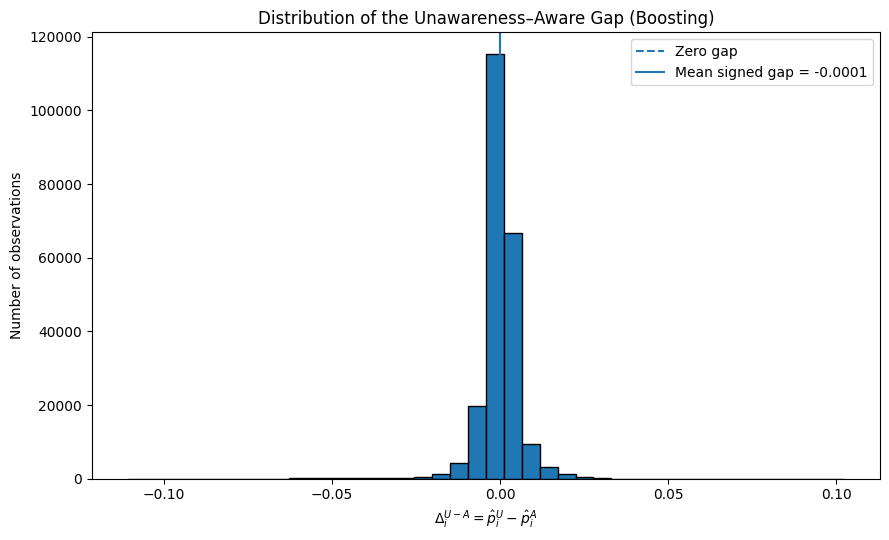

Saved: figures/boosting_gap_distribution.png
Mean signed gap:   -0.0001
Mean absolute gap: 0.0035
Saved: boosting_gap_deciles_table.csv


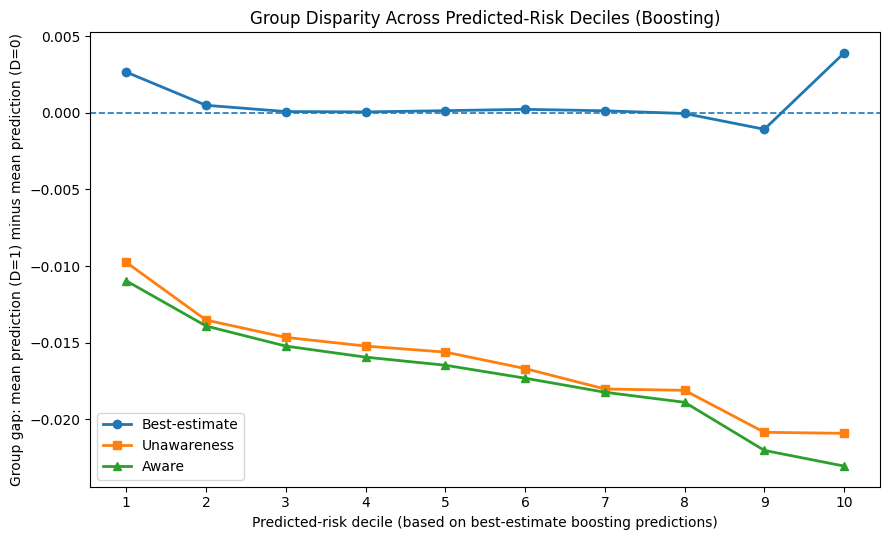

Saved: figures/boosting_gap_deciles.png


In [ ]:
# =========================
# ADDITIONAL FIGURES FOR THESIS:
# 1) Distribution of Delta^(U-A)
# 2) Group disparity across predicted-risk deciles
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create figures folder if it does not exist
figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

# -------------------------------------------------
# Figure 1: Histogram of the unawareness-aware gap
# -------------------------------------------------

# Observation-level gap for the boosting model
delta_ua_boosting = (
    pd.Series(pred_unawareness_xgb_prob).reset_index(drop=True)
    - pd.Series(pred_aware_xgb_prob).reset_index(drop=True)
)

mean_signed_gap_boosting = delta_ua_boosting.mean()
mean_absolute_gap_boosting = delta_ua_boosting.abs().mean()

plt.figure(figsize=(9, 5.5))
plt.hist(delta_ua_boosting, bins=40, edgecolor="black")
plt.axvline(0, linestyle="--", linewidth=1.5, label="Zero gap")
plt.axvline(mean_signed_gap_boosting, linestyle="-", linewidth=1.5,
            label=f"Mean signed gap = {mean_signed_gap_boosting:.4f}")

plt.title("Distribution of the Unawareness–Aware Gap (Boosting)")
plt.xlabel(r"$\Delta_i^{U-A} = \hat{p}_i^{U} - \hat{p}_i^{A}$")
plt.ylabel("Number of observations")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "boosting_gap_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figures_dir / "boosting_gap_distribution.png")
print(f"Mean signed gap:   {mean_signed_gap_boosting:.4f}")
print(f"Mean absolute gap: {mean_absolute_gap_boosting:.4f}")


# ----------------------------------------------------------------
# Figure 2: Group disparity across predicted-risk deciles
# ----------------------------------------------------------------
# Idea:
# - Use the best-estimate boosting prediction as the baseline risk score
# - Create predicted-risk deciles
# - Within each decile, compute the group gap:
#       mean(pred | D=1) - mean(pred | D=0)
# - Do this for Best-estimate, Unawareness, and Aware

decile_df = pd.DataFrame({
    "baseline_risk": pd.Series(pred_best_estimate_xgb_prob).reset_index(drop=True),
    "SexVP": pd.Series(X_test_fair_all[D_col]).reset_index(drop=True).astype(int),
    "best_estimate_pred": pd.Series(pred_best_estimate_xgb_prob).reset_index(drop=True),
    "unawareness_pred": pd.Series(pred_unawareness_xgb_prob).reset_index(drop=True),
    "aware_pred": pd.Series(pred_aware_xgb_prob).reset_index(drop=True)
})

# Create risk deciles based on best-estimate predicted risk
decile_df["risk_decile"] = pd.qcut(
    decile_df["baseline_risk"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1


def compute_group_gap_by_decile(df, pred_col):
    """
    For each risk decile, compute:
    gap = mean(prediction | D=1) - mean(prediction | D=0)
    """
    tmp = (
        df.groupby(["risk_decile", "SexVP"])[pred_col]
        .mean()
        .unstack()
        .reset_index()
    )

    # Make sure both columns exist
    if 0 not in tmp.columns:
        tmp[0] = np.nan
    if 1 not in tmp.columns:
        tmp[1] = np.nan

    tmp["gap_D1_minus_D0"] = tmp[1] - tmp[0]

    return tmp[["risk_decile", 0, 1, "gap_D1_minus_D0"]].rename(
        columns={
            0: "mean_pred_group0",
            1: "mean_pred_group1"
        }
    )


gap_best = compute_group_gap_by_decile(decile_df, "best_estimate_pred")
gap_unaw = compute_group_gap_by_decile(decile_df, "unawareness_pred")
gap_aware = compute_group_gap_by_decile(decile_df, "aware_pred")

# Combine into one clean table
decile_gap_table = pd.DataFrame({
    "risk_decile": gap_best["risk_decile"],
    "gap_best_estimate": gap_best["gap_D1_minus_D0"],
    "gap_unawareness": gap_unaw["gap_D1_minus_D0"],
    "gap_aware": gap_aware["gap_D1_minus_D0"]
})

# Save supporting table
decile_gap_table.to_csv("boosting_gap_deciles_table.csv", index=False)
print("Saved: boosting_gap_deciles_table.csv")

# Plot
plt.figure(figsize=(9, 5.5))
plt.plot(decile_gap_table["risk_decile"], decile_gap_table["gap_best_estimate"],
         marker="o", linewidth=2, label="Best-estimate")
plt.plot(decile_gap_table["risk_decile"], decile_gap_table["gap_unawareness"],
         marker="s", linewidth=2, label="Unawareness")
plt.plot(decile_gap_table["risk_decile"], decile_gap_table["gap_aware"],
         marker="^", linewidth=2, label="Aware")

plt.axhline(0, linestyle="--", linewidth=1.2)
plt.xticks(decile_gap_table["risk_decile"])
plt.title("Group Disparity Across Predicted-Risk Deciles (Boosting)")
plt.xlabel("Predicted-risk decile (based on best-estimate boosting predictions)")
plt.ylabel("Group gap: mean prediction (D=1) minus mean prediction (D=0)")
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "boosting_gap_deciles.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", figures_dir / "boosting_gap_deciles.png")